In [1]:
import os
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import yaml
from datetime import datetime


In [2]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [3]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [4]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner, MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_LSTM_mult import model_LSTM_mult
from src.util import Logger, Util

/Users/ishizuka/opt/anaconda3/envs/mufgcup2024/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# データ読み込み

In [178]:
dict_dtype_station = {
    "station_id": "int64",
    "lat": "float64",
    "long": "float64",
    "dock_count": "int64",
    "city": "object",
    "installation_date": "object",
}
dict_dtype_status = {
    "id": "int64",
    "year": "int64",
    "month": "int64",
    "day": "int64",
    "hour": "int64",
    "station_id": "int64",
    "bikes_available": "float64",
    "predict": "int64",
}
dict_dtype_trip = {
    "trip_id": "int64",
    "duration": "int64",
    "start_date": "object",
    "start_station_id": "int64",
    "end_date": "object",
    "end_station_id": "int64",
    "bike_id": "int64",
    "subscription_type": "object",
}
dict_dtype_weather = {
    "date": "object",
    "max_temperature": "int64",
    "mean_temperature": "int64",
    "min_temperature": "int64",
    "max_dew_point": "int64",
    "mean_dew_point": "int64",
    "min_dew_point": "int64",
    "max_humidity": "int64",
    "mean_humidity": "int64",
    "min_humidity": "int64",
    "max_sea_level_pressure": "float64",
    "mean_sea_level_pressure": "float64",
    "min_sea_level_pressure": "float64",
    "max_visibility": "int64",
    "mean_visibility": "int64",
    "min_visibility": "int64",
    "max_wind_Speed": "int64",
    "mean_wind_speed": "int64",
    "precipitation": "float64",
    "cloud_cover": "int64",
    "events": "object",
    "wind_dir_degrees": "int64",
}

In [179]:
df_station = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATION), dtype=dict_dtype_station)
df_status = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATUS), dtype=dict_dtype_status)
df_trip = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_TRIP), dtype=dict_dtype_trip)
df_weather = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_WEATHER), dtype=dict_dtype_weather)

# 前処理

In [16]:
def convert_datetime(df_station, df_status, df_trip, df_weather):
    df_station["installation_date"] = pd.to_datetime(df_station["installation_date"], format='%m/%d/%Y').dt.date
    df_status["datetime"] = pd.to_datetime(df_status[["year", "month", "day", "hour"]])
    df_trip["start_date"] = pd.to_datetime(df_trip["start_date"], format='%m/%d/%Y %H:%M')
    df_trip["end_date"] = pd.to_datetime(df_trip["end_date"], format='%m/%d/%Y %H:%M')
    df_weather["date"] = pd.to_datetime(df_weather["date"], format='%Y-%m-%d').dt.date

    return df_station, df_status, df_trip, df_weather

In [17]:
df_station, df_status, df_trip, df_weather = convert_datetime(df_station, df_status, df_trip, df_weather)

In [18]:
# データ出力
df_station.to_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_status.to_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_trip.to_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_weather.to_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

# 特徴量作成

In [19]:
from pathlib import Path
from abc import ABCMeta, abstractmethod

In [20]:
from time import time

def decorate(s: str, decoration=None):
    if decoration is None:
        decoration = '★' * 20
        
    return ' '.join([decoration, str(s), decoration])

class Timer:
    def __init__(self, logger=None, format_str='{:.3f}[s]', prefix=None, suffix=None, sep=' ', verbose=0):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None
        self.verbose = verbose

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        if self.verbose is None:
            return
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

In [21]:
class AbstractBaseBlock(metaclass=ABCMeta):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        self.use_cache = use_cache
        self.name = self.__class__.__name__
        self.cache_dir = Path(DIR_FEATURE)
        self.logger = logger
        self.seve_cache = save_cache
        self.use_cols = None
        
    # 内部状態の更新
    def fit(self, df_input: pd.DataFrame, y=None):
        pass
    
    # 変換処理
    @abstractmethod
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        raise NotImplementedError()
    
    # 内部状態の更新と変換処理をまとめて行う
    def fit_transform(self, X: pd.DataFrame, y=None):
        self.fit(X, y)
        return self.transform(X)
    
    # 特徴量生成処理
    def create_feature(self, X, y=None, test=False, limit_date="yyyy-mm-dd") -> pd.DataFrame:

        # クラス名.pkl
        file_name = os.path.join(self.cache_dir, limit_date, f"{self.name}.pkl")

        # キャッシュを使う & ファイルがあるなら読み出し
        if os.path.isfile(str(file_name)) and self.use_cache:
            return pd.read_pickle(file_name)
        
        # 変換処理を実行
        else:
            # trainの場合
            if not test:
                feature = self.fit_transform(X, y)
            # testの場合
            else:
                feature = self.transform(X)
            # 保存する場合
            if self.seve_cache:
                feature.to_pickle(file_name)

            return feature

In [22]:
# そのままの特徴量を返すBlock

In [23]:
# 静的特徴量
# 動的特徴量

In [24]:
class AsIsNumetricBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'CityTier', 
            'DurationOfPitch',
            'NumberOfPersonVisiting',
            'NumberOfFollowups', 
            'PreferredPropertyStar', 
            'NumberOfTrips',
            'Passport', 
            'PitchSatisfactionScore',
            'MonthlyIncome', 
            'ProdTaken' # 目的関数
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

class AsIsCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'Age', 
            'TypeofContact',
            'Occupation',
            'Gender',
            'ProductPitched',
            'Designation', 
            'customer_info', 
            'marry', 
            'car', 
            'child',
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

In [25]:
class CountEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_count = None

    def fit(self, df_input, y=None):
        # カラムごとにマッピング表を作成
        self.map_count = {}
        for col in self.use_cols:
            self.map_count[col] = df_input[col].fillna("NA").value_counts()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].fillna("NA").map(self.map_count[col]).astype(int)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('CE_')], axis=1)
        return df_result
        
class TargetEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y):
        # カラムごとにマッピング表を作成
        self.map_target = {}
        for col in self.use_cols:
            self.map_target[col] = df_input.groupby(col)[TARGET_COL].mean()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].map(self.map_target[col]).astype(float)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('TE_')], axis=1)
        return df_result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result
    
# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result
    
    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

In [26]:
def run_blocks(df_input, feature_blocks, y=None, test=False):
    df_out = None
    
    print(decorate('start run blocks...'))

    with Timer(prefix='run test={}'.format(test)):
        for block in feature_blocks:
            with Timer(prefix='\t- {}'.format(str(block))):
                feature = block.create_feature(df_input, y=y, test=test)
            assert len(df_input) == len(feature), block
            if df_out is None:
                df_out = feature
            else:
                df_out = pd.merge(df_out, feature, on=["id"], how="left")

    return df_out

In [27]:
feature_blocks = [
    *[AsIsCategoryBlock(use_cache=False, save_cache=True, logger=None)],
    *[AsIsNumetricBlock(use_cache=True, save_cache=True, logger=None)],
    *[CountEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[TargetEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[BigCategoryBlock(use_cache=True, save_cache=True, logger=None)],
]

In [ ]:
df_preprocessed = pd.read_pickle(os.path.join(DIR_INTERIM, "preprocessed.pkl"))

In [212]:
df_out = run_blocks(df_preprocessed, feature_blocks, y=None, test=False)

★★★★★★★★★★★★★★★★★★★★ start run blocks... ★★★★★★★★★★★★★★★★★★★★
	- <__main__.AsIsCategoryBlock object at 0x7fd57ad0a400> 0.034[s]
	- <__main__.AsIsNumetricBlock object at 0x7fd57ad0a8b0> 0.004[s]
	- <__main__.CountEncodingBlock object at 0x7fd57ad0a8e0> 0.002[s]
	- <__main__.TargetEncodingBlock object at 0x7fd57ad0a940> 0.001[s]
	- <__main__.BigCategoryBlock object at 0x7fd57ad0ac70> 0.001[s]
run test=False 0.069[s]


# 特徴量生成

In [6]:
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_prep_trip = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))

In [7]:
# keyデータの作成
df_key = df_prep_status[["station_id", "datetime"]].copy()

In [21]:
# 目的変数
df_target = df_prep_status[["station_id", "datetime", "bikes_available"]].copy()

In [22]:
# predictデータの作成
df_predict = df_prep_status[["station_id", "datetime", "predict"]].copy()

In [166]:
# 欠損値補完した時系列データの作成
df_bikes_available_ = df_prep_status[["station_id", "datetime", "predict", "bikes_available"]].copy()
## 各ステーション毎に、欠損値を埋める
df_bikes_available_fillna = pd.DataFrame()
for station_id in df_bikes_available_["station_id"].unique().tolist():
    temp_df = df_bikes_available_[df_bikes_available_["station_id"]==station_id]
    ## 前の値で欠損値補完
    temp_df = temp_df.ffill()
    ## predict==1のデータをnullにする
    temp_df.loc[temp_df["predict"]==1, "bikes_available"] = np.nan
    df_bikes_available_fillna = pd.concat([df_bikes_available_fillna,temp_df])

df_bikes_available_fillna.drop(columns=["predict"], inplace=True)

print(df_bikes_available_[["bikes_available"]].isnull().sum())
print(df_bikes_available_fillna[["bikes_available"]].isnull().sum())

bikes_available    218522
dtype: int64
bikes_available    214805
dtype: int64


In [24]:
# ラグ特徴量の作成
def create_lag_feature(df, key_cols, target_cols, lag):
    df_lag = df[key_cols].copy()
    for target_col in target_cols:
        for i in range(0, lag+1):
            df_shift = df[key_cols + [target_col]].copy()
            df_shift["datetime"] = df_shift["datetime"] + pd.Timedelta(hours=i)
            df_shift.columns = key_cols + [f"{target_col}_lag{i}"]
            df_lag = pd.merge(df_lag, df_shift, on=key_cols, how="left")
    return df_lag


lag = 24
target_cols = ["bikes_available"]
df_lag = create_lag_feature(df_prep_status, ["station_id", "datetime"], target_cols, lag)

In [25]:
# 曜日特徴量の作成
df_weekday = df_prep_status.copy()[["datetime"]].drop_duplicates()
df_weekday["weekday"] = df_weekday["datetime"].dt.weekday

In [26]:
# diff・需要・供給・予測データの作成
trip_data = df_prep_trip.copy()
trip_data['start_hour'] = pd.to_datetime(trip_data['start_date']).dt.floor('h')
trip_data['end_hour'] = pd.to_datetime(trip_data['end_date']).dt.floor('h')

## 出発（需要）を集計
## 過去1時間の需要を集計
departures = trip_data.groupby(['start_station_id', 'start_hour']).size().reset_index(name='demand')
departures["datetime"] = departures["start_hour"] + pd.Timedelta(hours=1)
departures.rename(columns={"start_station_id": "station_id"}, inplace=True)
## 到着（供給）を集計
## 過去1時間の供給を集計
arrivals = trip_data.groupby(['end_station_id', 'end_hour']).size().reset_index(name='supply')
arrivals["datetime"] = arrivals["end_hour"] + pd.Timedelta(hours=1)
arrivals.rename(columns={"end_station_id": "station_id"}, inplace=True)

## bikes_availableを需要・供給・介入に分解
df_status_detail = df_prep_status[["station_id", "datetime", "bikes_available"]].copy()
df_status_detail['datetime'] = pd.to_datetime(df_status_detail['datetime']).dt.floor('h')

## 前の時間との利用可能数の差分を計算
df_status_detail = df_status_detail.sort_values(['station_id', 'datetime'])
df_status_detail['bikes_available_diff'] = df_status_detail.groupby('station_id')['bikes_available'].diff()

## 需要・供給を結合
df_status_detail = df_status_detail.merge(departures, on=['station_id', 'datetime'], how='left')
df_status_detail = df_status_detail.merge(arrivals, on=['station_id', 'datetime'], how='left')
df_status_detail["demand"] = -df_status_detail["demand"]
df_status_detail["demand"] = df_status_detail["demand"].fillna(0)
df_status_detail["supply"] = df_status_detail["supply"].fillna(0)

## 介入を計算
## 過去１時間の介入を計算
df_status_detail['intervention'] = df_status_detail['bikes_available_diff'] - (df_status_detail['demand'] + df_status_detail['supply'])

# df_status_detail = df_status_detail[['station_id', 'datetime', 'demand', 'supply', 'intervention']]

In [27]:
df_demand = df_status_detail[['station_id', 'datetime', 'demand']].copy()
df_supply = df_status_detail[['station_id', 'datetime', 'supply']].copy()
df_intervention = df_status_detail[['station_id', 'datetime', 'intervention']].copy()

In [28]:
# 需要・供給・介入のラグ特徴量を作成
df_demand_lag = create_lag_feature(df_demand, ["station_id", "datetime"], ["demand"], 24)
df_supply_lag = create_lag_feature(df_supply, ["station_id", "datetime"], ["supply"], 24)
df_intervention_lag = create_lag_feature(df_intervention, ["station_id", "datetime"], ["intervention"], 24)

In [29]:
# 各日の00:00からの変化数に変換
def calc_cumsum_from_00(df_, col):
    df_["date"] = df_["datetime"].dt.date
    df_[f"{col}_cumsum"] = df_.groupby(["station_id", "date"])[col].cumsum()
    df_ = df_.drop(columns=[col, "date"])
    return df_

df_demand_cumsum = calc_cumsum_from_00(df_demand, "demand")
df_supply_cumsum = calc_cumsum_from_00(df_supply, "supply")
df_intervention_cumsum = calc_cumsum_from_00(df_intervention, "intervention")


In [30]:
# cumsumのラグ特徴量を作成
df_demand_cumsum_lag = create_lag_feature(df_demand_cumsum, ["station_id", "datetime"], ["demand_cumsum"], 24)
df_supply_cumsum_lag = create_lag_feature(df_supply_cumsum, ["station_id", "datetime"], ["supply_cumsum"], 24)
df_intervention_cumsum_lag = create_lag_feature(df_intervention_cumsum, ["station_id", "datetime"], ["intervention_cumsum"], 24)

In [31]:
# 全ての目的変数を作成
df_target_all = df_target.copy()
df_target_all["demand"] = df_status_detail["demand"]
df_target_all["supply"] = df_status_detail["supply"]
df_target_all["intervention"] = df_status_detail["intervention"]
df_target_all["demand_cumsum"] = df_demand_cumsum["demand_cumsum"]
df_target_all["supply_cumsum"] = df_supply_cumsum["supply_cumsum"]
df_target_all["intervention_cumsum"] = df_intervention_cumsum["intervention_cumsum"]
df_target_all["demand_suplly_cumsum"] = df_target_all["demand_cumsum"] + df_target_all["supply_cumsum"]
df_target_all.to_pickle(os.path.join(DIR_INTERIM, "df_target_all.pkl"))

In [146]:
df_target_all[df_target_all["datetime"].dt.hour==0]

,station_id,datetime,bikes_available,demand,supply,intervention,demand_cumsum,supply_cumsum,intervention_cumsum,demand_suplly_cumsum
0,0,2013-09-01,11.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0
24,0,2013-09-02,12.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
48,0,2013-09-03,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72,0,2013-09-04,9.0,-1.0,0.0,1.0,-1.0,0.0,1.0,-1.0
96,0,2013-09-05,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1226280,69,2015-08-27,4.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0
1226304,69,2015-08-28,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1226328,69,2015-08-29,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1226352,69,2015-08-30,8.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0


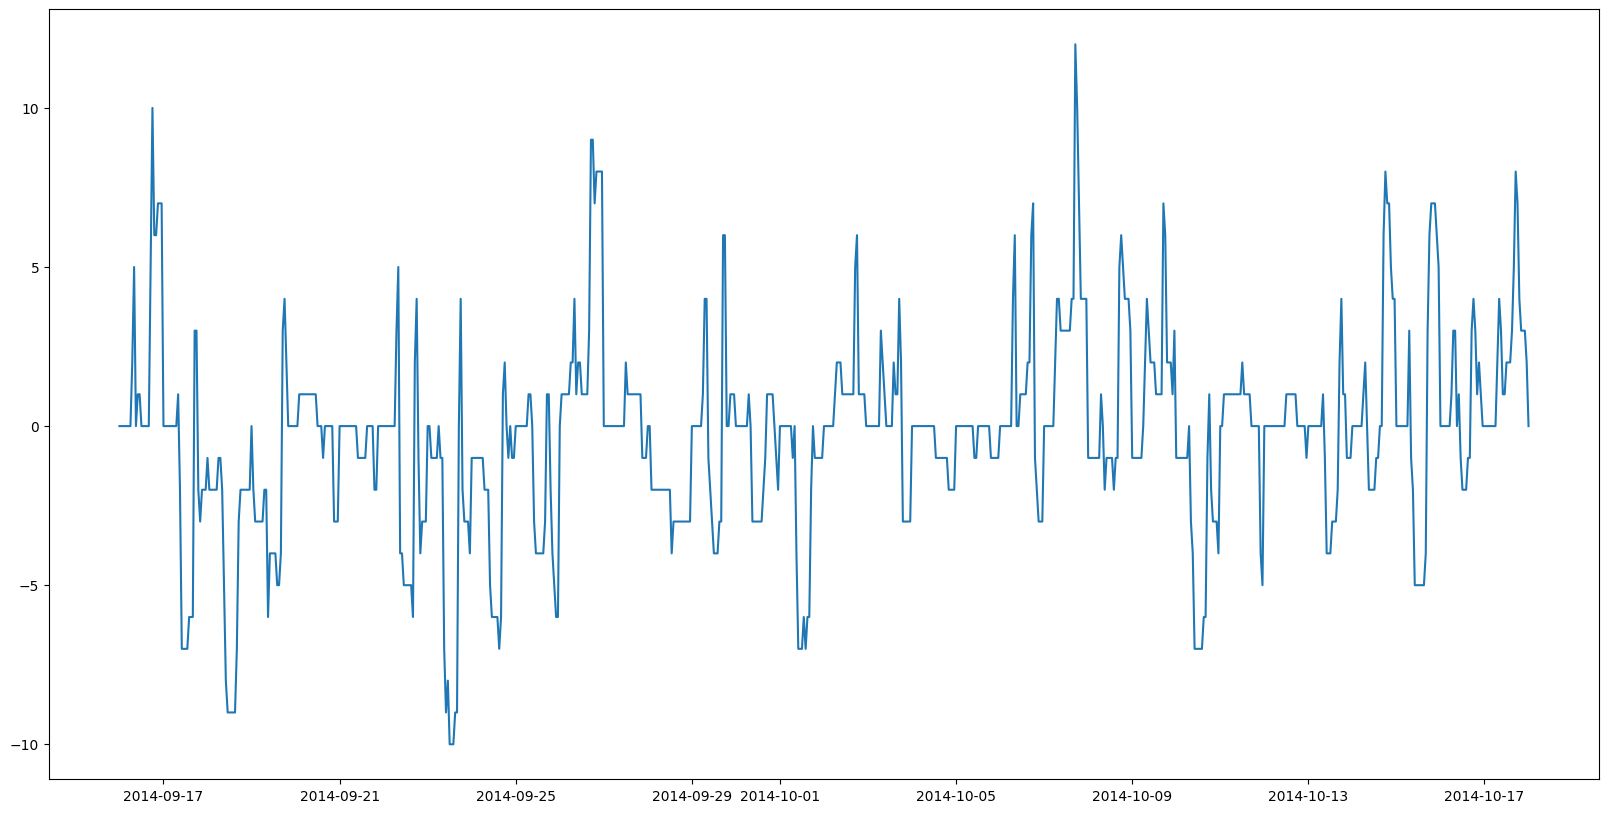

In [160]:
# demand_cumsumをプロット
# 期間を絞る
df_ = df_target_all.copy()
col = "demand_suplly_cumsum"
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[col])
plt.show()

In [72]:
# キーの重複を確認
df_ = df_status_detail_feat_lag
print(df_[["station_id", "datetime"]].duplicated().sum())
print()
# 欠損値の確認
print(df_.isnull().sum())

0

station_id                 0
datetime                   0
demand_lag0                0
demand_lag1               70
demand_lag2              140
                       ...  
intervention_lag20    228892
intervention_lag21    228962
intervention_lag22    229032
intervention_lag23    229102
intervention_lag24    229172
Length: 77, dtype: int64


# モデル別データセットを作成

In [84]:
# LGBM用データセット
df_main_lgb = df_key.copy()
df_main_lgb = pd.merge(df_main_lgb, df_target, on=["station_id","datetime"], how="left")
df_main_lgb = pd.merge(df_main_lgb, df_predict, on=["station_id","datetime"], how="left")
df_main_lgb = pd.merge(df_main_lgb, df_lag, on=["station_id","datetime"], how="left")
df_main_lgb = pd.merge(df_main_lgb, df_weekday, on=["datetime"], how="left")
df_main_lgb = pd.merge(df_main_lgb, df_status_detail_lag, on=["station_id","datetime"], how="left")

In [85]:
df_main_lgb.head()

,station_id,datetime,bikes_available,predict,bikes_available_lag0,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,...,intervention_lag15,intervention_lag16,intervention_lag17,intervention_lag18,intervention_lag19,intervention_lag20,intervention_lag21,intervention_lag22,intervention_lag23,intervention_lag24
0,0,2013-09-01 00:00:00,11.0,0,11.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2013-09-01 01:00:00,11.0,0,11.0,11.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2013-09-01 02:00:00,11.0,0,11.0,11.0,11.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,2013-09-01 03:00:00,11.0,0,11.0,11.0,11.0,11.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,2013-09-01 04:00:00,11.0,0,11.0,11.0,11.0,11.0,11.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# LSTM用データセット
df_main_lstm = df_key.copy()
df_main_lstm = pd.merge(df_main_lstm, df_predict, on=["station_id","datetime"], how="left")
df_main_lstm = pd.merge(df_main_lstm, df_timeseries_fillna, on=["station_id","datetime"], how="left")
df_main_lstm = pd.merge(df_main_lstm, df_weekday, on=["datetime"], how="left")

In [26]:
df_main_lstm.head()

,station_id,datetime,predict,bikes_available,weekday
0,0,2013-09-01 00:00:00,0,11.0,6
1,0,2013-09-01 01:00:00,0,11.0,6
2,0,2013-09-01 02:00:00,0,11.0,6
3,0,2013-09-01 03:00:00,0,11.0,6
4,0,2013-09-01 04:00:00,0,11.0,6


# 検証用データセット化

In [33]:
# 検証データにフラグを立てる
def create_valid_flag(df_result):
    # テストデータと2日以上離れているデータを検証データとする
    df_ = df_result.copy()
    df_ = df_[df_["predict"] != 0]
    df_["date"] = df_["datetime"].dt.date
    df_ = df_[["date","predict"]].drop_duplicates()
    df_["diff"] = df_["date"].diff().dt.days
    df_["yesterday"] = df_["date"].apply(lambda x: x - pd.Timedelta(days=1))
    list_valid_date = df_[df_["diff"] >= 4.0]["yesterday"].tolist()
    # dateがlist_valid_dateに含まれている場合はpredictを2にする
    df_result_ = df_result.copy()
    df_result_["predict"] = df_result_.apply(lambda x: 2 if (x["datetime"].date() in list_valid_date) & (x["datetime"].hour!=0) else x["predict"], axis=1)
    return df_result_

def create_add_valid_dataset(df_main):
    """検証データのフラグを立てる
    """
    df_main_ = df_main.copy()
    df_main_ = df_main_.sort_values(["datetime","station_id"],ascending=True).reset_index(drop=True)
    past_2_len = 0
    while True:
        df_main_ = create_valid_flag(df_main_)
        current_2_len = len(df_main_[df_main_["predict"] == 2])
        if current_2_len == past_2_len:
            break
        past_2_len = current_2_len

    return df_main_

In [90]:
df_main_lgb_new = create_add_valid_dataset(df_main_lgb)
df_main_lgb_new.to_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

In [88]:
df_main_lgb_new.groupby("predict").size()

predict
0    928550
1    193200
2    104650
dtype: int64

In [29]:
df_main_lstm_new = create_add_valid_dataset(df_main_lstm)
df_main_lstm_new.to_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))


In [30]:
df_main_lstm_new.groupby("predict").size()

predict
0    928550
1    193200
2    104650
dtype: int64

In [34]:
df_predict_ = create_add_valid_dataset(df_predict)

# LGBM_台数

In [91]:
df_main_lgb_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lgb_new.pkl"))

In [182]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from datetime import datetime
from src.util import Logger

In [93]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [94]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [95]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

In [96]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multimodel")
# run_name = 'lgbm_multimodel_202410132324'
run_name

'lgbm_multimodel_202410141742'

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [97]:
model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [98]:
memo = "LightGBM23期マルチモデル 需要・供給・介入の単純ラグ特徴量追加"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel, 
    model_params_lgb, 
    df_main_lgb_new, 
    run_setting, 
    cv_setting, 
    logger, 
    memo)

In [101]:
ml_runner.run_train_cv()

[2024-10-14 17:45:04] - lgbm_multimodel_202410141742 - start training cv
[2024-10-14 17:45:04] - lgbm_multimodel_202410141742 fold 2014-09-01 - start training


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1969
[LightGBM] [Info] Number of data points in the train set: 22398, number of used features: 101
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.27682	eval's l1: 1.4532
[200]	train's l1: 0.694557	eval's l1: 0.828888
[300]	train's l1: 0.454578	eval's l1: 0.547453
[400]	train's l1: 0.32607	eval's l1: 0.385456
[500]	train's l1: 0.239585	eval's l1: 0.28091
[600]	train's l1: 0.197652	eval's l1: 0.232204
[700]	train's l1: 0.177094	eval's l1: 0.208765
[800]	train's l1: 0.170486	eval's l1: 0.198616
[900]	train's l1: 0.167679	eval's l1: 0.19366
[1000]	train's l1: 0.166219	eval's l1: 0.191289
[1100]	train's l1: 0.166165	eval's l1: 0.191212
[1200]	train's l1:

[2024-10-14 17:47:46] - lgbm_multimodel_202410141742 fold 2014-09-01 - end training
[2024-10-14 17:47:46] - lgbm_multimodel_202410141742 fold 2014-10-01 - start training


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2015
[LightGBM] [Info] Number of data points in the train set: 24566, number of used features: 101
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.29667	eval's l1: 1.43189
[200]	train's l1: 0.729241	eval's l1: 0.839976
[300]	train's l1: 0.508364	eval's l1: 0.562915
[400]	train's l1: 0.358527	eval's l1: 0.394693
[500]	train's l1: 0.269252	eval's l1: 0.287469
[600]	train's l1: 0.212498	eval's l1: 0.207706
[700]	train's l1: 0.193328	eval's l1: 0.181577
[800]	train's l1: 0.184452	eval's l1: 0.171464
[900]	train's l1: 0.18218	eval's l1: 0.167864
[1000]	train's l1: 0.180932	eval's l1: 0.167389
[1100]	train's l1: 0.180765	eval's l1: 0.167053
[1200]	train's 

[2024-10-14 17:50:02] - lgbm_multimodel_202410141742 fold 2014-10-01 - end training
[2024-10-14 17:50:02] - lgbm_multimodel_202410141742 fold 2014-11-01 - start training


...

[2024-10-14 18:15:31] - lgbm_multimodel_202410141742 fold 2015-06-01 - end training
[2024-10-14 18:15:31] - lgbm_multimodel_202410141742 fold 2015-07-01 - start training


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2119
[LightGBM] [Info] Number of data points in the train set: 37305, number of used features: 101
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.37044	eval's l1: 1.46233
[200]	train's l1: 0.632662	eval's l1: 0.660519
[300]	train's l1: 0.438743	eval's l1: 0.452557
[400]	train's l1: 0.332203	eval's l1: 0.331398
[500]	train's l1: 0.274031	eval's l1: 0.266655
[600]	train's l1: 0.226931	eval's l1: 0.191333
[700]	train's l1: 0.199855	eval's l1: 0.152115
[800]	train's l1: 0.187541	eval's l1: 0.131687
[900]	train's l1: 0.183053	eval's l1: 0.12412
[1000]	train's l1: 0.179915	eval's l1: 0.120698
[1100]	train's l1: 0.178161	eval's l1: 0.119581
[1200]	train's 

[2024-10-14 18:18:56] - lgbm_multimodel_202410141742 fold 2015-07-01 - end training
[2024-10-14 18:18:56] - lgbm_multimodel_202410141742 fold 2015-08-01 - start training


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2124
[LightGBM] [Info] Number of data points in the train set: 38703, number of used features: 101
[LightGBM] [Info] Start training from score 8.000000
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 1.37402	eval's l1: 1.29492
[200]	train's l1: 0.664036	eval's l1: 0.597075
[300]	train's l1: 0.462379	eval's l1: 0.400751
[400]	train's l1: 0.324879	eval's l1: 0.27529
[500]	train's l1: 0.257421	eval's l1: 0.220391
[600]	train's l1: 0.212194	eval's l1: 0.181681
[700]	train's l1: 0.194094	eval's l1: 0.172893
[800]	train's l1: 0.183224	eval's l1: 0.169372
[900]	train's l1: 0.181118	eval's l1: 0.168294
[1000]	train's l1: 0.180915	eval's l1: 0.168137
[1100]	train's l1: 0.180836	eval's l1: 0.168076
[1200]	train's 

[2024-10-14 18:22:18] - lgbm_multimodel_202410141742 fold 2015-08-01 - end training
[2024-10-14 18:22:18] - lgbm_multimodel_202410141742 - end training cv


In [102]:
ml_runner.run_metric_cv()

[2024-10-14 18:22:19] - lgbm_multimodel_202410141742 - start metric cv
100%|██████████| 12/12 [05:19<00:00, 26.62s/it]
memo: LightGBM23期マルチモデル 需要・供給・介入の単純ラグ特徴量追加
run_name:lgbm_multimodel_202410141742	score_mean:1.5818574186854804	score0:1.7223903084342054	score1:1.7938440408057255	score2:1.5383887805845962	score3:1.5330597235923216	score4:1.549797874920564	score5:1.396096620029498	score6:1.5946996222407854	score7:1.5225594622937813	score8:1.5134409237148003	score9:1.6150017614473335	score10:1.668324417744468	score11:1.5346854884176881
mean: 1.5818574186854804, std: 0.10151178678056098
[2024-10-14 18:27:38] - mean: 1.5818574186854804, std: 0.10151178678056098
[2024-10-14 18:27:38] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multimodel_202410141742/va_pred.pkl
[2024-10-14 18:27:38] - lgbm_multimodel_202410141742 - end metric cv


In [103]:
ml_runner.run_predict_cv()

[2024-10-14 18:27:38] - lgbm_multimodel_202410141742 - start prediction cv
100%|██████████| 12/12 [04:48<00:00, 24.07s/it]
[2024-10-14 18:32:27] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multimodel_202410141742/te_pred.pkl
[2024-10-14 18:32:27] - lgbm_multimodel_202410141742 - end prediction cv


In [104]:
ml_runner.plot_feature_importance_cv()

[2024-10-14 18:32:27] - lgbm_multimodel_202410141742 - start plot feature importance cv
[2024-10-14 18:33:18] - lgbm_multimodel_202410141742 - end plot feature importance cv


In [16]:
# 予測値確認

In [106]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル 需要・供給・介入の単純ラグ特徴量追加


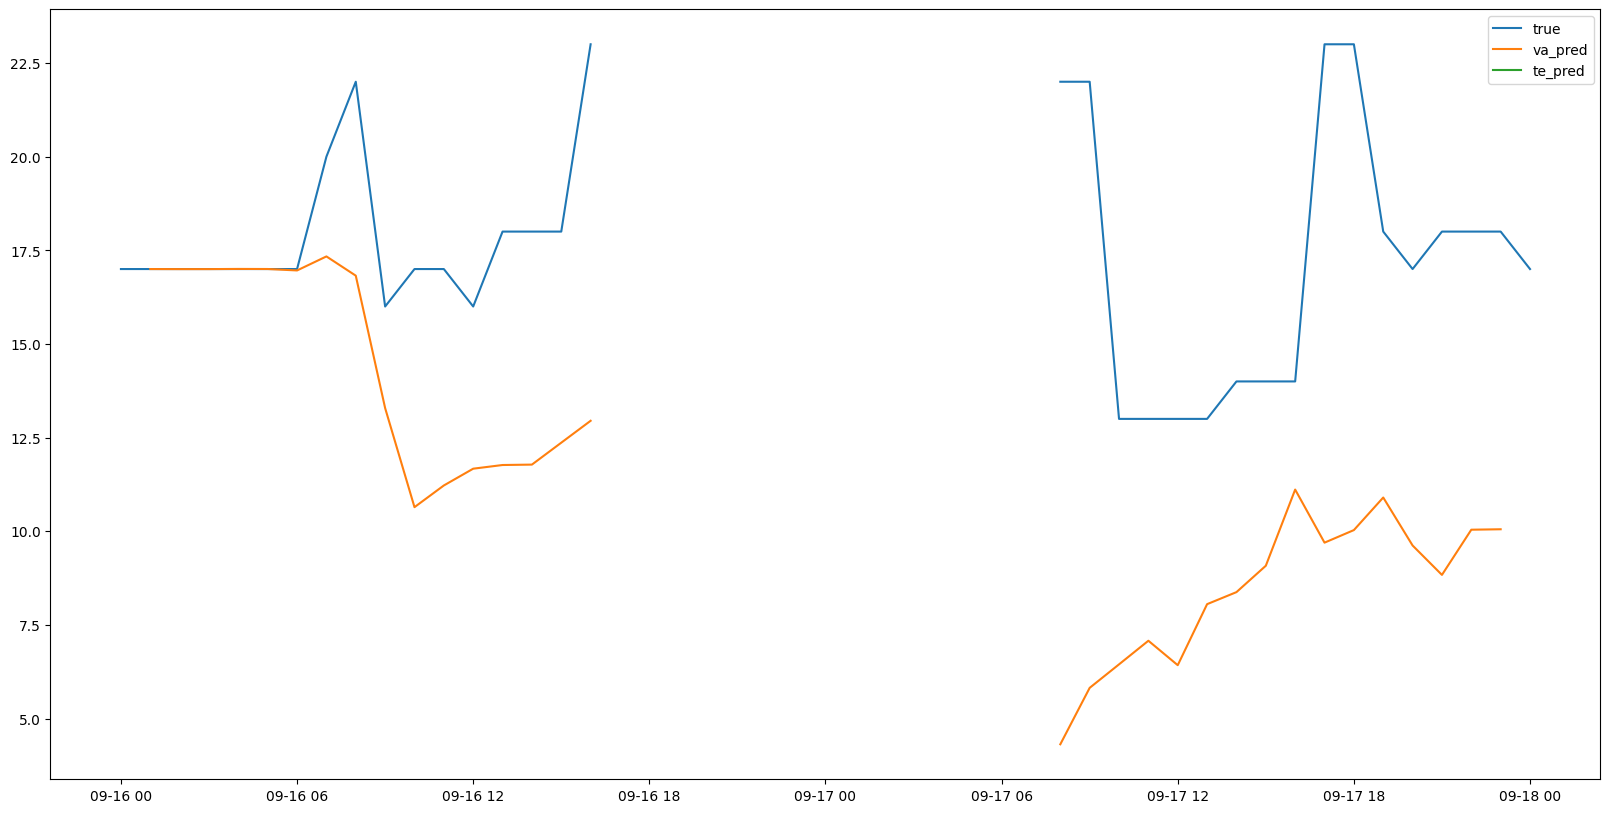

In [107]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LightGBM23期マルチモデル


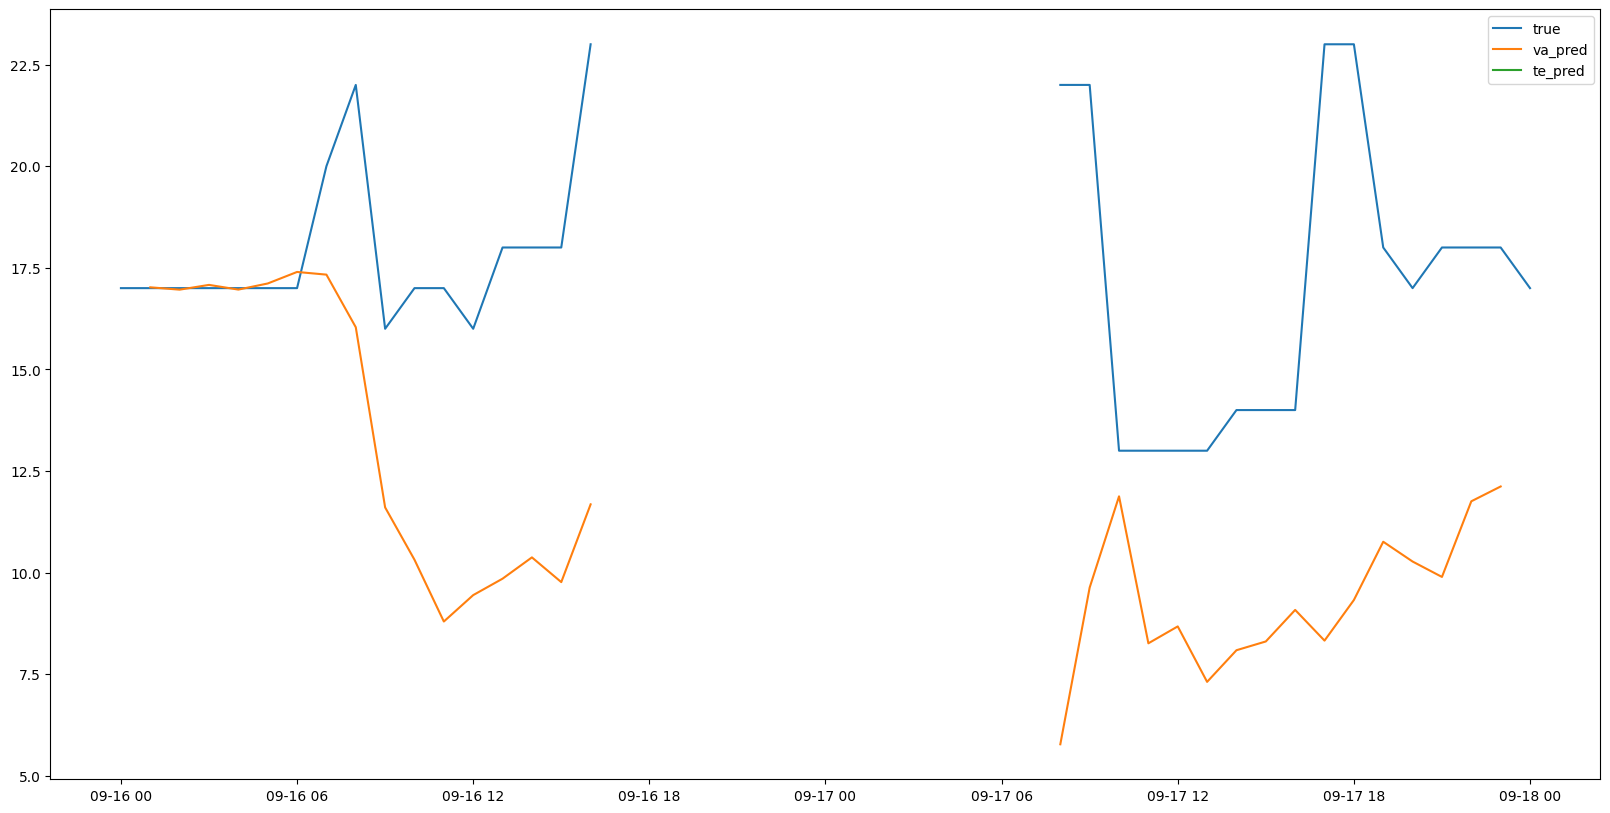

In [225]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_台数

In [5]:
df_main_lstm_new = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_lstm_new.pkl"))

In [6]:
df_main_lstm_new

,station_id,datetime,predict,bikes_available,weekday
0,0,2013-09-01 00:00:00,0,11.0,6
1,1,2013-09-01 00:00:00,0,8.0,6
2,2,2013-09-01 00:00:00,0,5.0,6
3,3,2013-09-01 00:00:00,0,9.0,6
4,4,2013-09-01 00:00:00,0,8.0,6
...,...,...,...,...,...
1226395,65,2015-08-31 23:00:00,0,13.0,0
1226396,66,2015-08-31 23:00:00,0,7.0,0
1226397,67,2015-08-31 23:00:00,0,6.0,0
1226398,68,2015-08-31 23:00:00,0,5.0,0


In [7]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from datetime import datetime
from src.util import Logger

In [16]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [8]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [9]:
logger = Logger(path=DIR_LOG)

In [11]:
run_name = get_run_name(model_type="lstm_mult")
# run_name = 'lstm_mult_202410132245'
run_name

'lstm_mult_202410181108'

In [12]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [13]:
model_params = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [14]:
memo = "LSTMのマルチステップ予測 後処理追加"
timeseries_runner = TimeseriesModelRunner(run_name,
                                          model_LSTM_mult, 
                                          model_params, 
                                          df_main_lstm_new, 
                                          run_setting,
                                          cv_setting,
                                          logger, 
                                          memo)

In [48]:
timeseries_runner.run_train_cv()

[2024-10-18 11:08:36] - lstm_mult_202410181108 - start training cv
[2024-10-18 11:08:36] - lstm_mult_202410181108 fold 2014-09-01 - start training


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
24576 24576
(24576, 24, 2) (24576, 23)
torch.Size([24576, 24, 2]) torch.Size([24576, 23])
24576
384
2
model
criterion


In [14]:
timeseries_runner.run_metric_cv()

[2024-10-14 14:48:08] - lstm_mult_202410132245 - start metric cv
100%|██████████| 12/12 [00:23<00:00,  1.95s/it]
memo: LSTMのマルチステップ予測 後処理追加
run_name:lstm_mult_202410132245	score_mean:1.6819826614430216	score0:1.7368062295534643	score1:1.8970805470764205	score2:1.6028723657051864	score3:1.658505381214091	score4:1.6624859627015631	score5:1.5040819079485985	score6:1.702690100422395	score7:1.622700958258432	score8:1.617622394960939	score9:1.7418933251045943	score10:1.793829023956512	score11:1.6432237404140626
mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - mean: 1.6819826614430216, std: 0.09738140548426347
[2024-10-14 14:48:31] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/va_pred.pkl
[2024-10-14 14:48:31] - lstm_mult_202410132245 - end metric cv


In [18]:
timeseries_runner.run_predict_cv()

[2024-10-14 14:50:09] - lstm_mult_202410132245 - start prediction cv
100%|██████████| 12/12 [00:38<00:00,  3.17s/it]
[2024-10-14 14:50:48] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lstm_mult_202410132245/te_pred.pkl
[2024-10-14 14:50:48] - lstm_mult_202410132245 - end prediction cv


In [53]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LSTMのマルチステップ予測 学習率0.001 epoch5


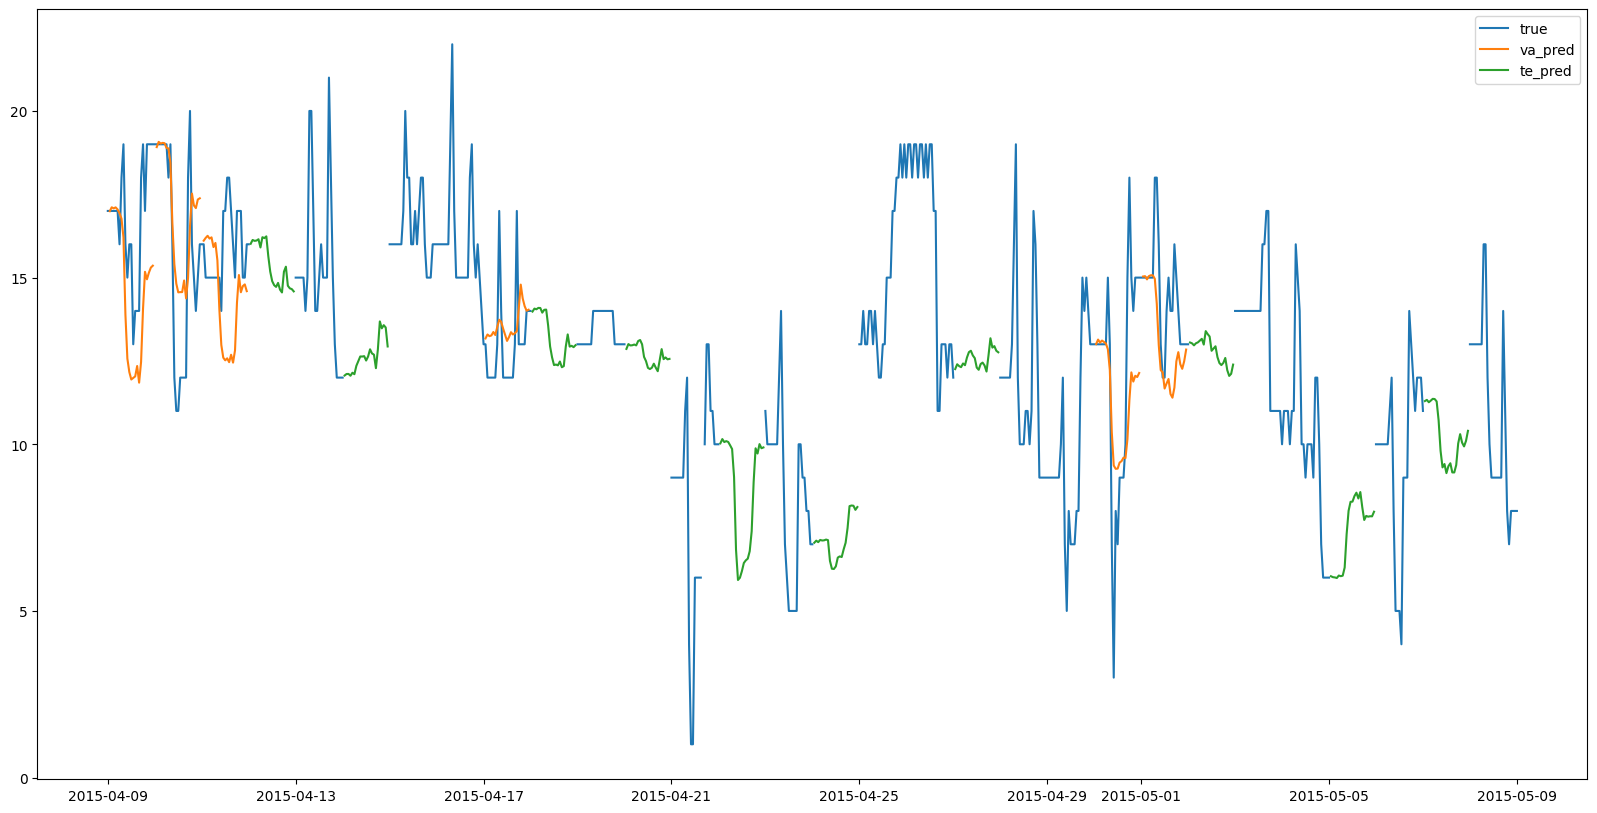

In [54]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

LSTMのマルチステップ予測 学習率0.001 epoch5


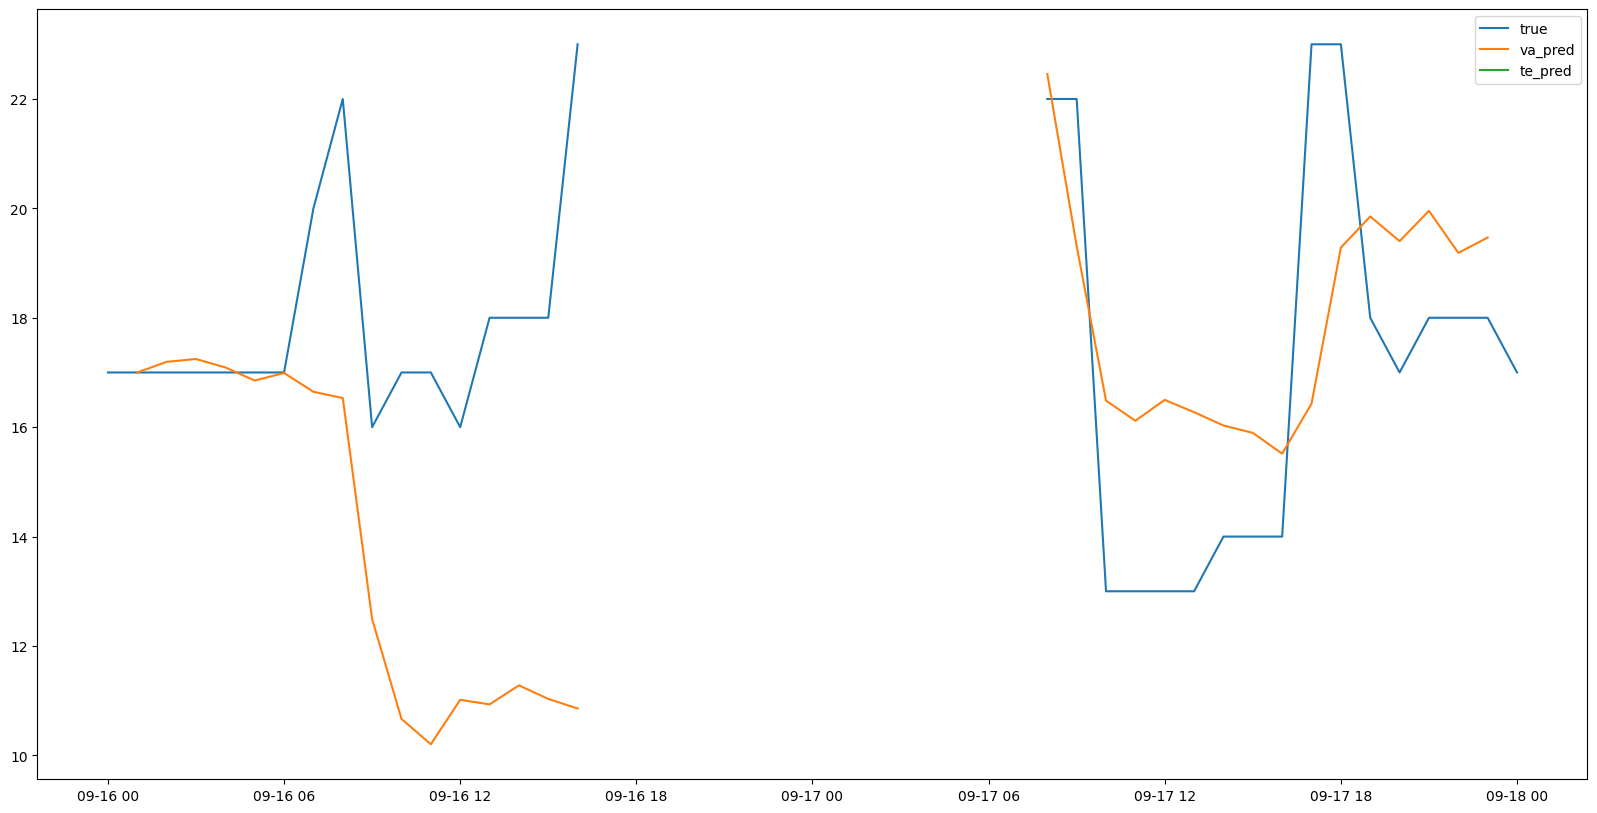

In [55]:
# 元の目的関数が欠損している部分（）
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-09-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [56]:
# 学習データ数の推移
for month in range(8, 13):
    i_fold = datetime(2014, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

for month in range(1, 9):
    i_fold = datetime(2015, month, 1)
    tr, tr_va_te, list_va_date, list_te_date = timeseries_runner.craete_train_valid_dateset(i_fold)
    model_ = model_LSTM_mult("sample", model_params, logger)
    self = model_
    feat_cols = [col for col in tr.columns.to_list() if col not in self.key_cols]
    x, y, list_key = self.create_sequences_for_forecast(tr, self.key_cols, feat_cols, self.seq_length, self.n_steps)
    print(i_fold, x.shape)

2014-08-01 00:00:00 (22406, 24, 2)
2014-09-01 00:00:00 (24576, 24, 2)
2014-10-01 00:00:00 (25276, 24, 2)
2014-11-01 00:00:00 (26046, 24, 2)
2014-12-01 00:00:00 (26746, 24, 2)
2015-01-01 00:00:00 (27516, 24, 2)
2015-02-01 00:00:00 (28286, 24, 2)
2015-03-01 00:00:00 (28846, 24, 2)
2015-04-01 00:00:00 (29616, 24, 2)
2015-05-01 00:00:00 (30316, 24, 2)
2015-06-01 00:00:00 (31086, 24, 2)
2015-07-01 00:00:00 (31786, 24, 2)
2015-08-01 00:00:00 (32556, 24, 2)


# LGBM_需要

In [126]:

df_main_demand = df_key.copy()
df_main_demand = pd.merge(df_main_demand, df_predict, on=["station_id","datetime"], how="left")
df_main_demand = pd.merge(df_main_demand, df_target_detail[["station_id","datetime","demand_cumsum"]], on=["station_id","datetime"], how="left")
df_main_demand = pd.merge(df_main_demand, df_target_detail_lag, on=["station_id","datetime"], how="left")
df_main_demand = pd.merge(df_main_demand, df_weekday, on=["datetime"], how="left")

df_main_new_demand = create_add_valid_dataset(df_main_demand)


In [128]:
df_main_new_demand.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_demand.pkl"))

In [7]:
df_main_new_demand = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_demand.pkl"))

In [155]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [177]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [178]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_demand")
run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_demand_202410142258'

In [180]:
# ロガーの設定
logger = Logger(path=DIR_LOG)


In [11]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

In [12]:
model_params_lgb_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [13]:
memo = "LightGBM23期マルチモデル demand_cumsum"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel, 
    model_params_lgb_demand, 
    df_main_new_demand, 
    run_setting_lgb_demand, 
    cv_setting_lgb_demand, 
    logger, 
    memo)

In [185]:
ml_runner.run_train_cv()

[2024-10-14 22:58:24] - lgbm_multiml_demand_202410142258 - start training cv
[2024-10-14 22:58:24] - lgbm_multiml_demand_202410142258 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 76), tr_y: (23380, 1), va_x: (2170, 76), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3797
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0873851	eval's l1: 0.103038
[200]	train's l1: 0.0716833	eval's l1: 0.0847514
[300]	train's l1: 0.065936	eval's l1: 0.0780581
[400]	train's l1: 0.0638322	eval's l1: 0.0756081
[500]	train's l1: 0.0630622	eval's l1: 0.0747113
[600]	train's l1: 0.0627804	eval's l1: 0.0743831
[700]	train's l1: 0.0626772	eval's l1: 0.0742629
[800]	train's l1: 0.0626394	eval's l1: 0.0742189
[900]	train's l1: 0.0626256	eval's l1: 0.0742028
[1000]	train's l1: 0.0626205	eval's l1: 0.074197
[1100]	train's l1

[2024-10-14 23:00:59] - lgbm_multiml_demand_202410142258 fold 2014-09-01 - end training
[2024-10-14 23:00:59] - lgbm_multiml_demand_202410142258 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 76), tr_y: (25550, 1), va_x: (420, 76), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3999
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0887145	eval's l1: 0.102974
[200]	train's l1: 0.0727932	eval's l1: 0.0875034
[300]	train's l1: 0.0669655	eval's l1: 0.0818408
[400]	train's l1: 0.0648324	eval's l1: 0.0797681
[500]	train's l1: 0.0640516	eval's l1: 0.0790095
[600]	train's l1: 0.0637658	eval's l1: 0.0787318
[700]	train's l1: 0.0636612	eval's l1: 0.0786301
[800]	train's l1: 0.0636229	eval's l1: 0.0785929
[900]	train's l1: 0.0636089	eval's l1: 0.0785793
[1000]	train's l1: 0.0636037	eval's l1: 0.0785743
[1100]	train's l1

[2024-10-14 23:02:49] - lgbm_multiml_demand_202410142258 fold 2014-10-01 - end training
[2024-10-14 23:02:49] - lgbm_multiml_demand_202410142258 fold 2014-11-01 - start training


...

[2024-10-14 23:33:06] - lgbm_multiml_demand_202410142258 fold 2015-06-01 - end training
[2024-10-14 23:33:06] - lgbm_multiml_demand_202410142258 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 76), tr_y: (44660, 1), va_x: (280, 76), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005829 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4764
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0862966	eval's l1: 0.0348872
[200]	train's l1: 0.070028	eval's l1: 0.0241133
[300]	train's l1: 0.0640732	eval's l1: 0.0201698
[400]	train's l1: 0.0618935	eval's l1: 0.0187263
[500]	train's l1: 0.0610957	eval's l1: 0.0181979
[600]	train's l1: 0.0608036	eval's l1: 0.0180045
[700]	train's l1: 0.0606967	eval's l1: 0.0179337
[800]	train's l1: 0.0606576	eval's l1: 0.0179078
[900]	train's l1: 0.0606433	eval's l1: 0.0178983
[1000]	train's l1: 0.060638	eval's l1: 0.0178949
[1100]	train's l1:

[2024-10-14 23:36:16] - lgbm_multiml_demand_202410142258 fold 2015-07-01 - end training
[2024-10-14 23:36:16] - lgbm_multiml_demand_202410142258 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 76), tr_y: (46760, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006997 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4781
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0855963	eval's l1: 0.0793565
[200]	train's l1: 0.0694678	eval's l1: 0.0634443
[300]	train's l1: 0.0635642	eval's l1: 0.0576199
[400]	train's l1: 0.0614033	eval's l1: 0.055488
[500]	train's l1: 0.0606124	eval's l1: 0.0547077
[600]	train's l1: 0.0603228	eval's l1: 0.0544221
[700]	train's l1: 0.0602169	eval's l1: 0.0543175
[800]	train's l1: 0.0601781	eval's l1: 0.0542792
[900]	train's l1: 0.0601639	eval's l1: 0.0542652
[1000]	train's l1: 0.0601587	eval's l1: 0.0542601
[1100]	train's l1

[2024-10-14 23:39:10] - lgbm_multiml_demand_202410142258 fold 2015-08-01 - end training
[2024-10-14 23:39:10] - lgbm_multiml_demand_202410142258 - end training cv


In [14]:
ml_runner.run_metric_cv()

[2024-10-15 16:47:27] - lgbm_multiml_demand_202410142258 - start metric cv
100%|██████████| 12/12 [03:57<00:00, 19.77s/it]
memo: LightGBM23期マルチモデル demand_cumsum
run_name:lgbm_multiml_demand_202410142258	score_mean:2.2507819233241975	score0:2.345910104402896	score1:2.344884720360136	score2:3.0850323653663043	score3:1.3618085294342033	score4:2.1062527879190407	score5:2.4927756248810184	score6:2.3263839264255113	score7:1.6118102714642555	score8:1.6074637485535763	score9:3.0685704553691773	score10:2.3470963222588477	score11:2.3113942234554017
mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/va_pred.pkl
[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - end metric cv


In [15]:
ml_runner.run_predict_cv()

[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - start prediction cv
100%|██████████| 12/12 [03:32<00:00, 17.73s/it]
[2024-10-15 16:54:58] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/te_pred.pkl
[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - end prediction cv


In [16]:
ml_runner.plot_feature_importance_cv()

[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - start plot feature importance cv
[2024-10-15 16:55:38] - lgbm_multiml_demand_202410142258 - end plot feature importance cv


In [17]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_demand[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル demand_cumsum


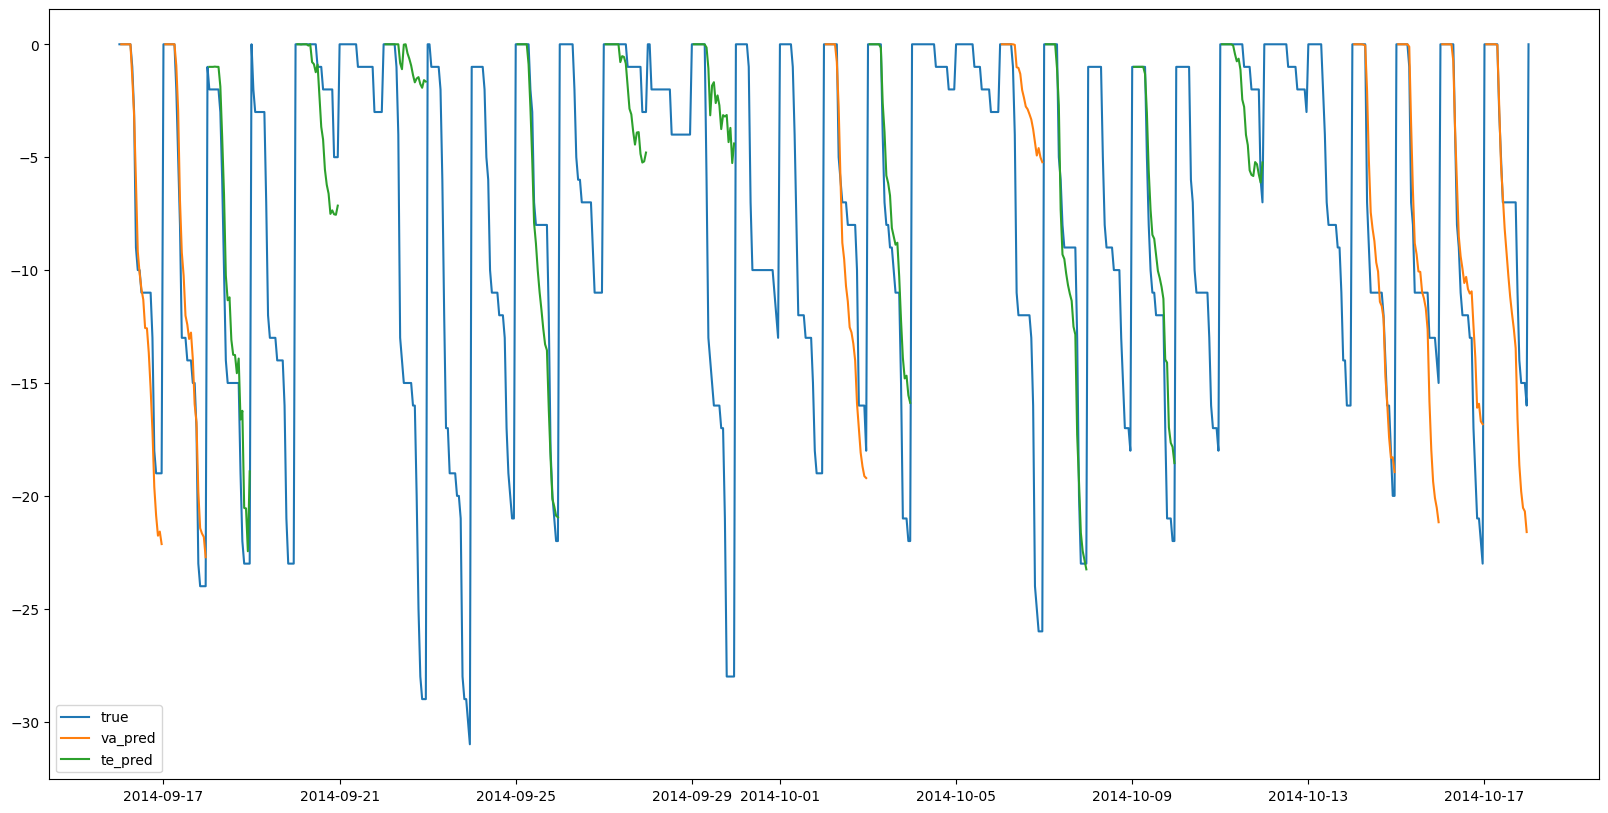

In [18]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_供給

In [34]:

df_main_supply = df_key.copy()
df_main_supply = pd.merge(df_main_supply, df_predict, on=["station_id","datetime"], how="left")
df_main_supply = pd.merge(df_main_supply, df_target_detail[["station_id","datetime","supply_cumsum"]], on=["station_id","datetime"], how="left")
df_main_supply = pd.merge(df_main_supply, df_target_detail_lag, on=["station_id","datetime"], how="left")
df_main_supply = pd.merge(df_main_supply, df_weekday, on=["datetime"], how="left")

df_main_new_supply = create_add_valid_dataset(df_main_supply)


In [35]:
df_main_new_supply.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_supply.pkl"))

In [36]:
df_main_new_supply = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_supply.pkl"))

In [37]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [38]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [39]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_supply")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_supply_202410151702'

In [40]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

In [41]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)

    return df_pred

In [48]:
model_params_lgb_supply = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_supply = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_supply = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [49]:
memo = "LightGBM23期マルチモデル demand_supply"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel, 
    model_params_lgb_supply, 
    df_main_new_supply, 
    run_setting_lgb_supply, 
    cv_setting_lgb_supply, 
    logger, 
    memo)

In [51]:
ml_runner.run_train_cv()

[2024-10-15 17:08:09] - lgbm_multiml_supply_202410151702 - start training cv
[2024-10-15 17:08:09] - lgbm_multiml_supply_202410151702 fold 2014-09-01 - start training


term: 1, tr_x: (23380, 76), tr_y: (23380, 1), va_x: (2170, 76), va_y: (2170, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3797
[LightGBM] [Info] Number of data points in the train set: 23380, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0995893	eval's l1: 0.117866
[200]	train's l1: 0.0825476	eval's l1: 0.0992589
[300]	train's l1: 0.0763098	eval's l1: 0.0924482
[400]	train's l1: 0.0740266	eval's l1: 0.0899552
[500]	train's l1: 0.0731908	eval's l1: 0.0890427
[600]	train's l1: 0.0728849	eval's l1: 0.0887087
[700]	train's l1: 0.072773	eval's l1: 0.0885864
[800]	train's l1: 0.072732	eval's l1: 0.0885417
[900]	train's l1: 0.072717	eval's l1: 0.0885253
[1000]	train's l1: 0.0727115	eval's l1: 0.0885193
[1100]	train's l1:

[2024-10-15 17:10:26] - lgbm_multiml_supply_202410151702 fold 2014-09-01 - end training
[2024-10-15 17:10:26] - lgbm_multiml_supply_202410151702 fold 2014-10-01 - start training


term: 1, tr_x: (25550, 76), tr_y: (25550, 1), va_x: (420, 76), va_y: (420, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3999
[LightGBM] [Info] Number of data points in the train set: 25550, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.101141	eval's l1: 0.109269
[200]	train's l1: 0.0839666	eval's l1: 0.0943511
[300]	train's l1: 0.0776801	eval's l1: 0.0888907
[400]	train's l1: 0.075379	eval's l1: 0.0868921
[500]	train's l1: 0.0745368	eval's l1: 0.0861605
[600]	train's l1: 0.0742285	eval's l1: 0.0858927
[700]	train's l1: 0.0741156	eval's l1: 0.0857947
[800]	train's l1: 0.0740743	eval's l1: 0.0857588
[900]	train's l1: 0.0740592	eval's l1: 0.0857457
[1000]	train's l1: 0.0740537	eval's l1: 0.0857409
[1100]	train's l1: 

[2024-10-15 17:12:37] - lgbm_multiml_supply_202410151702 fold 2014-10-01 - end training
[2024-10-15 17:12:37] - lgbm_multiml_supply_202410151702 fold 2014-11-01 - start training


...

[2024-10-15 17:33:41] - lgbm_multiml_supply_202410151702 fold 2015-06-01 - end training
[2024-10-15 17:33:41] - lgbm_multiml_supply_202410151702 fold 2015-07-01 - start training


term: 1, tr_x: (44660, 76), tr_y: (44660, 1), va_x: (280, 76), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4764
[LightGBM] [Info] Number of data points in the train set: 44660, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0990123	eval's l1: 0.0459161
[200]	train's l1: 0.0815954	eval's l1: 0.032656
[300]	train's l1: 0.0752202	eval's l1: 0.0278023
[400]	train's l1: 0.0728867	eval's l1: 0.0260257
[500]	train's l1: 0.0720326	eval's l1: 0.0253755
[600]	train's l1: 0.0717199	eval's l1: 0.0251374
[700]	train's l1: 0.0716055	eval's l1: 0.0250503
[800]	train's l1: 0.0715636	eval's l1: 0.0250184
[900]	train's l1: 0.0715483	eval's l1: 0.0250067
[1000]	train's l1: 0.0715426	eval's l1: 0.0250025
[1100]	train's l1

[2024-10-15 17:37:02] - lgbm_multiml_supply_202410151702 fold 2015-07-01 - end training
[2024-10-15 17:37:02] - lgbm_multiml_supply_202410151702 fold 2015-08-01 - start training


term: 1, tr_x: (46760, 76), tr_y: (46760, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4781
[LightGBM] [Info] Number of data points in the train set: 46760, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0981356	eval's l1: 0.0986195
[200]	train's l1: 0.080811	eval's l1: 0.0813813
[300]	train's l1: 0.0744697	eval's l1: 0.0750716
[400]	train's l1: 0.0721485	eval's l1: 0.072762
[500]	train's l1: 0.0712989	eval's l1: 0.0719167
[600]	train's l1: 0.0709879	eval's l1: 0.0716072
[700]	train's l1: 0.0708741	eval's l1: 0.071494
[800]	train's l1: 0.0708324	eval's l1: 0.0714525
[900]	train's l1: 0.0708172	eval's l1: 0.0714373
[1000]	train's l1: 0.0708116	eval's l1: 0.0714318
[1100]	train's l1: 

[2024-10-15 17:40:19] - lgbm_multiml_supply_202410151702 fold 2015-08-01 - end training
[2024-10-15 17:40:19] - lgbm_multiml_supply_202410151702 - end training cv


In [52]:
ml_runner.run_metric_cv()

[2024-10-15 17:57:15] - lgbm_multiml_supply_202410151702 - start metric cv
100%|██████████| 12/12 [03:40<00:00, 18.39s/it]
memo: LightGBM23期マルチモデル demand_supply
run_name:lgbm_multiml_supply_202410151702	score_mean:2.2753274820602436	score0:2.4336771180545194	score1:2.4461572233096947	score2:3.028422754355578	score3:1.4349659157196566	score4:2.122129326270325	score5:2.65382056744003	score6:2.346879040070308	score7:1.4985730014631347	score8:1.567200323825077	score9:3.0634702108354754	score10:2.416111528386863	score11:2.292522774992263
mean: 2.2753274820602436, std: 0.5200593040862866
[2024-10-15 18:00:55] - mean: 2.2753274820602436, std: 0.5200593040862866
[2024-10-15 18:00:55] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_supply_202410151702/va_pred.pkl
[2024-10-15 18:00:55] - lgbm_multiml_supply_202410151702 - end metric cv


In [53]:
ml_runner.run_predict_cv()

[2024-10-15 18:00:55] - lgbm_multiml_supply_202410151702 - start prediction cv
100%|██████████| 12/12 [03:34<00:00, 17.84s/it]
[2024-10-15 18:04:30] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_supply_202410151702/te_pred.pkl
[2024-10-15 18:04:30] - lgbm_multiml_supply_202410151702 - end prediction cv


In [54]:
ml_runner.plot_feature_importance_cv()

[2024-10-15 18:04:30] - lgbm_multiml_supply_202410151702 - start plot feature importance cv
[2024-10-15 18:05:10] - lgbm_multiml_supply_202410151702 - end plot feature importance cv


In [56]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_supply[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル demand_supply


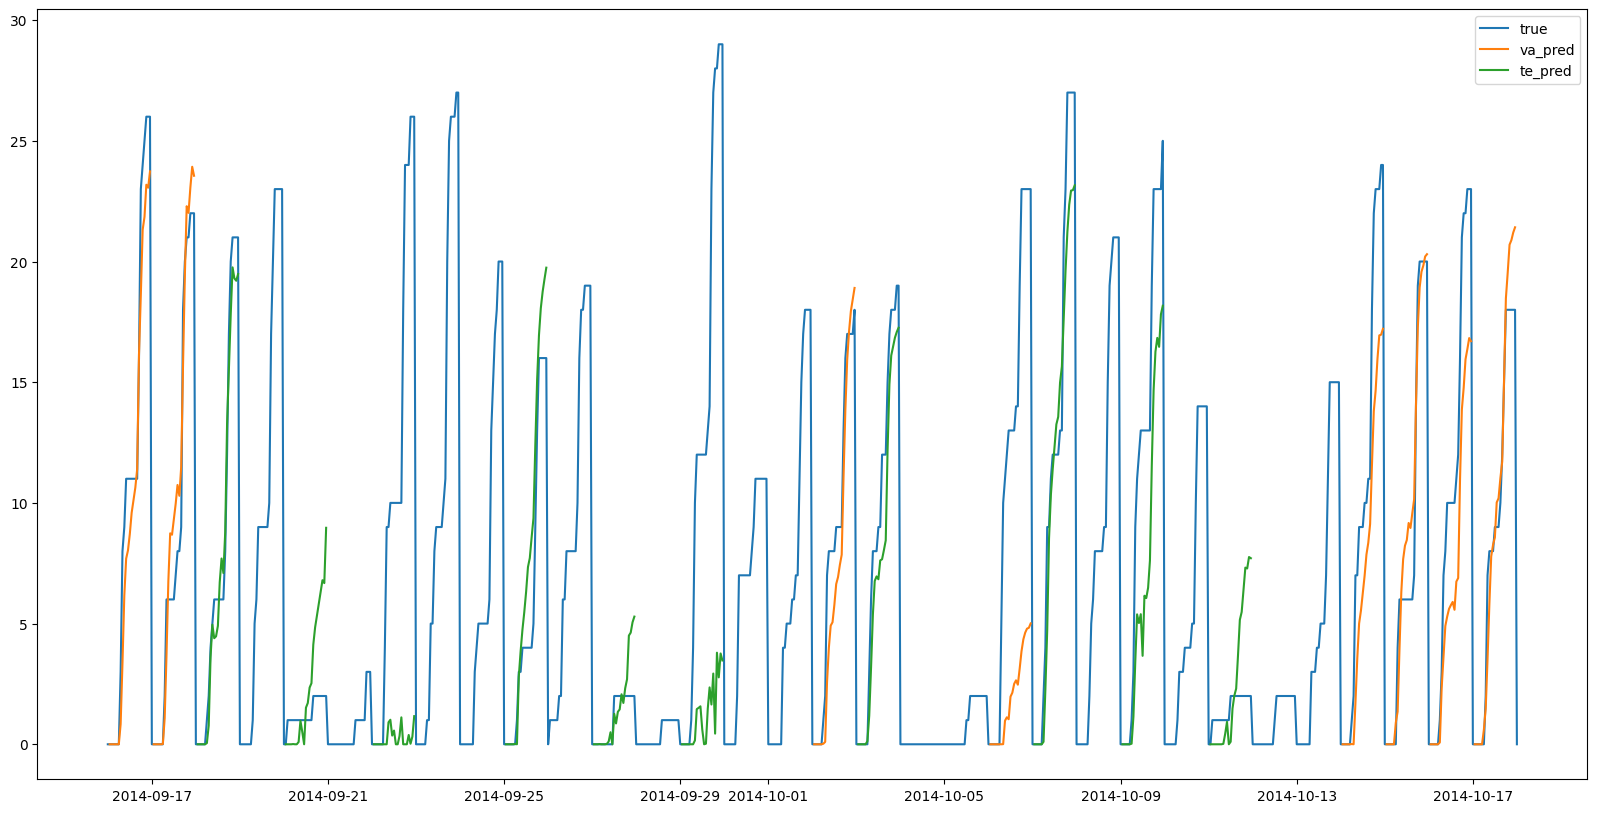

In [60]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LGBM_介入

In [20]:

df_main_intervention = df_key.copy()
df_main_intervention = pd.merge(df_main_intervention, df_predict, on=["station_id","datetime"], how="left")
df_main_intervention = pd.merge(df_main_intervention, df_target_all[["station_id","datetime","intervention_cumsum"]], on=["station_id","datetime"], how="left")
df_main_intervention = pd.merge(df_main_intervention, df_target_detail_lag, on=["station_id","datetime"], how="left")
df_main_intervention = pd.merge(df_main_intervention, df_weekday, on=["datetime"], how="left")

df_main_new_intervention = create_add_valid_dataset(df_main_intervention)


In [21]:
df_main_new_intervention.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_intervention.pkl"))

In [22]:
df_main_new_intervention = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_intervention.pkl"))

In [23]:
import importlib
from src import runner
from src import model_LGBM
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel

In [24]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [25]:
# run_nameの設定
run_name = get_run_name(model_type="lgbm_multiml_intervention")
# run_name = 'lgbm_multiml_demand_202410142258'
run_name

'lgbm_multiml_intervention_202410151853'

In [26]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

In [27]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    
    return df_pred

In [28]:
model_params_lgb_intervention = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
    # "num_leaves": 31,
    # "colsample_bytree": 0.5, # feature_fraction
    # "subsample": 0.5,
    # "reg_lambda": 5,
    # "random_state": 71,
    # 'max_depth': 3,
    # "min_data_in_leaf": 10,
    # "num_leaves": 31,
    # 'verbosity': -1,  # 出力を抑制
}
run_setting_lgb_intervention = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lgb_intervention = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [29]:
memo = "LightGBM23期マルチモデル intervention_cumsum"
ml_runner = MLModelRunner(
    run_name,
    model_LGBM_multimodel, 
    model_params_lgb_intervention, 
    df_main_new_intervention, 
    run_setting_lgb_intervention, 
    cv_setting_lgb_intervention, 
    logger, 
    memo)

In [30]:
ml_runner.run_train_cv()

[2024-10-15 18:54:57] - lgbm_multiml_intervention_202410151853 - start training cv
[2024-10-15 18:54:57] - lgbm_multiml_intervention_202410151853 fold 2014-09-01 - start training


term: 1, tr_x: (22398, 76), tr_y: (22398, 1), va_x: (2168, 76), va_y: (2168, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3797
[LightGBM] [Info] Number of data points in the train set: 22398, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.068737	eval's l1: 0.0802745
[200]	train's l1: 0.0639929	eval's l1: 0.0759082
[300]	train's l1: 0.062239	eval's l1: 0.074139
[400]	train's l1: 0.0613753	eval's l1: 0.0732914
[500]	train's l1: 0.0607794	eval's l1: 0.072946
[600]	train's l1: 0.0602991	eval's l1: 0.0734743
Early stopping, best iteration is:
[525]	train's l1: 0.0606659	eval's l1: 0.0728325
term: 2, tr_x: (22329, 76), tr_y: (22329, 1), va_x: (2168, 76), va_y: (2168, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-thre

[2024-10-15 18:57:09] - lgbm_multiml_intervention_202410151853 fold 2014-09-01 - end training
[2024-10-15 18:57:09] - lgbm_multiml_intervention_202410151853 fold 2014-10-01 - start training


term: 1, tr_x: (24566, 76), tr_y: (24566, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3999
[LightGBM] [Info] Number of data points in the train set: 24566, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.071024	eval's l1: 0.0577019
[200]	train's l1: 0.0671117	eval's l1: 0.0530474
[300]	train's l1: 0.065679	eval's l1: 0.0513437
[400]	train's l1: 0.0651409	eval's l1: 0.0507203
[500]	train's l1: 0.0649315	eval's l1: 0.0504928
[600]	train's l1: 0.0648462	eval's l1: 0.0504087
[700]	train's l1: 0.0648085	eval's l1: 0.0503777
[800]	train's l1: 0.0647845	eval's l1: 0.0503774
Early stopping, best iteration is:
[758]	train's l1: 0.0647949	eval's l1: 0.0503715
term: 2, tr_x: (24497, 76), tr_y:

[2024-10-15 18:58:51] - lgbm_multiml_intervention_202410151853 fold 2014-10-01 - end training
[2024-10-15 18:58:51] - lgbm_multiml_intervention_202410151853 fold 2014-11-01 - start training


...

[2024-10-15 19:14:28] - lgbm_multiml_intervention_202410151853 fold 2015-06-01 - end training
[2024-10-15 19:14:28] - lgbm_multiml_intervention_202410151853 fold 2015-07-01 - start training


term: 1, tr_x: (37305, 76), tr_y: (37305, 1), va_x: (280, 76), va_y: (280, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4554
[LightGBM] [Info] Number of data points in the train set: 37305, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0756965	eval's l1: 0.0563891
[200]	train's l1: 0.0721611	eval's l1: 0.0547282
[300]	train's l1: 0.0708503	eval's l1: 0.0541072
[400]	train's l1: 0.0703443	eval's l1: 0.0538486
[500]	train's l1: 0.0701197	eval's l1: 0.0529551
[600]	train's l1: 0.0699891	eval's l1: 0.0525648
[700]	train's l1: 0.069837	eval's l1: 0.0523191
[800]	train's l1: 0.0696494	eval's l1: 0.0523034
[900]	train's l1: 0.0695197	eval's l1: 0.0521665
Early stopping, best iteration is:
[879]	train's l1: 0.0695426	eval

[2024-10-15 19:20:54] - lgbm_multiml_intervention_202410151853 fold 2015-07-01 - end training
[2024-10-15 19:20:54] - lgbm_multiml_intervention_202410151853 fold 2015-08-01 - start training


term: 1, tr_x: (38703, 76), tr_y: (38703, 1), va_x: (350, 76), va_y: (350, 1)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4580
[LightGBM] [Info] Number of data points in the train set: 38703, number of used features: 76
Training until validation scores don't improve for 100 rounds
[100]	train's l1: 0.0750117	eval's l1: 0.0618549
[200]	train's l1: 0.0714088	eval's l1: 0.0571905
[300]	train's l1: 0.0700901	eval's l1: 0.0554832
[400]	train's l1: 0.0695818	eval's l1: 0.0548547
[500]	train's l1: 0.0690578	eval's l1: 0.053825
[600]	train's l1: 0.0686781	eval's l1: 0.0524705
[700]	train's l1: 0.0685431	eval's l1: 0.0520101
[800]	train's l1: 0.0684098	eval's l1: 0.0518593
[900]	train's l1: 0.068248	eval's l1: 0.051855
Early stopping, best iteration is:
[849]	train's l1: 0.0683311	eval's

[2024-10-15 19:23:09] - lgbm_multiml_intervention_202410151853 fold 2015-08-01 - end training
[2024-10-15 19:23:09] - lgbm_multiml_intervention_202410151853 - end training cv


In [31]:
ml_runner.run_metric_cv()

[2024-10-15 19:23:35] - lgbm_multiml_intervention_202410151853 - start metric cv
100%|██████████| 12/12 [04:05<00:00, 20.46s/it]
memo: LightGBM23期マルチモデル intervention_cumsum
run_name:lgbm_multiml_intervention_202410151853	score_mean:1.7212248859278116	score0:1.9853312730502588	score1:2.2363864495063335	score2:1.9383629507319897	score3:1.3091183158386546	score4:1.6443686689256	score5:1.6676085385734392	score6:1.5833785006487704	score7:1.585041290680082	score8:1.4268082636685213	score9:2.0353157099120605	score10:1.6811530169049949	score11:1.5618256526930367
mean: 1.7212248859278116, std: 0.2599361518344766
[2024-10-15 19:27:40] - mean: 1.7212248859278116, std: 0.2599361518344766
[2024-10-15 19:27:40] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_intervention_202410151853/va_pred.pkl
[2024-10-15 19:27:40] - lgbm_multiml_intervention_202410151853 - end metric cv


In [32]:
ml_runner.run_predict_cv()

[2024-10-15 19:27:41] - lgbm_multiml_intervention_202410151853 - start prediction cv
100%|██████████| 12/12 [03:39<00:00, 18.31s/it]
[2024-10-15 19:31:20] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_intervention_202410151853/te_pred.pkl
[2024-10-15 19:31:20] - lgbm_multiml_intervention_202410151853 - end prediction cv


In [33]:
ml_runner.plot_feature_importance_cv()

[2024-10-15 19:31:20] - lgbm_multiml_intervention_202410151853 - start plot feature importance cv
[2024-10-15 19:32:00] - lgbm_multiml_intervention_202410151853 - end plot feature importance cv


In [35]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_intervention[ml_runner.key_cols+[ml_runner.target_col]]

LightGBM23期マルチモデル intervention_cumsum


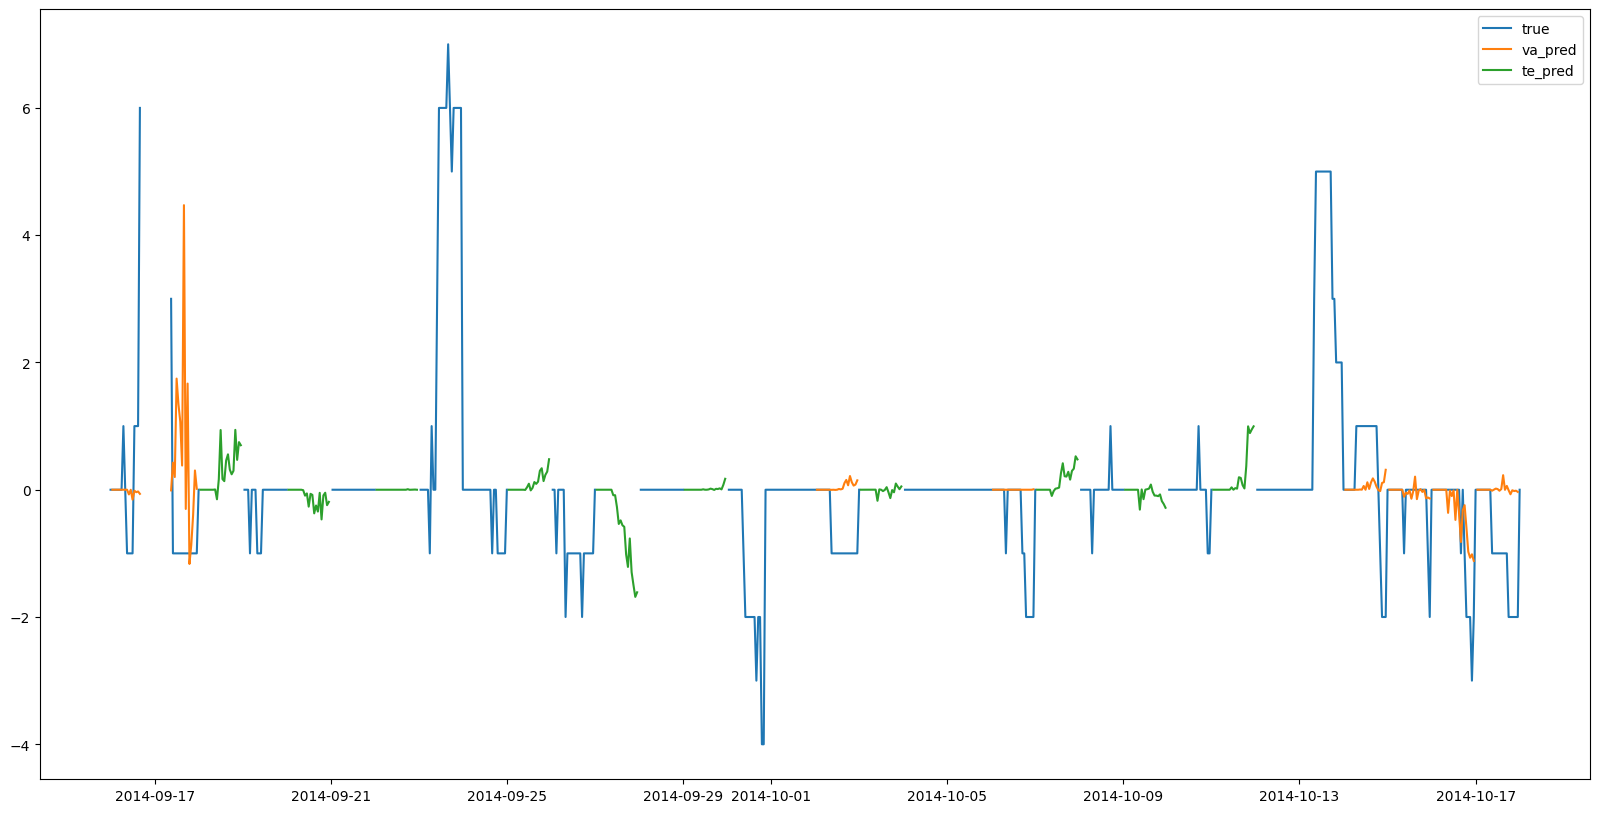

In [39]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{ml_runner.target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_需要

In [ ]:
df_main_demand_lstm = df_key.copy()
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_predict_, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_demand_cumsum, on=["station_id","datetime"], how="left")
df_main_demand_lstm = pd.merge(df_main_demand_lstm, df_weekday, on=["datetime"], how="left")

In [184]:
df_main_demand_lstm.to_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl"))

In [5]:
df_main_demand_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_demand_lstm.pkl"))

In [19]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [20]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

# run_nameの設定
run_name = get_run_name(model_type="lstm_mult_demand")
# run_name = 'lstm_demand_202410142258'
run_name

'lstm_mult_demand_202410181158'

In [21]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(upper=0)

    return df_pred

model_params_lstm_demand = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "seq_length": 24,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}
run_setting_lstm_demand = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lstm_demand = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "demand_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [22]:
memo = "LSTM demand_cumsum ベースライン"
timeseries_runner = TimeseriesModelRunner(
    run_name,
    model_LSTM_mult, 
    model_params_lstm_demand, 
    df_main_demand_lstm, 
    run_setting_lstm_demand, 
    cv_setting_lstm_demand, 
    logger, 
    memo)

In [ ]:
timeseries_runner.run_train_cv()

[2024-10-18 11:58:43] - lstm_mult_demand_202410181158 - start training cv


[2024-10-18 11:58:43] - lstm_mult_demand_202410181158 fold 2014-09-01 - start training


25480 25480
(25480, 24, 2) (25480, 23)
torch.Size([25480, 24, 2]) torch.Size([25480, 23])


In [ ]:
timeseries_runner.run_train_cv()

[2024-10-18 11:48:53] - lstm_mult_demand_202410181148 - start training cv
[2024-10-18 11:48:53] - lstm_mult_demand_202410181148 fold 2014-09-01 - start training


24
model
criterion
start training


NameError: name 'tr_loader' is not defined

In [ ]:
timeseries_runner.run_metric_cv()

[2024-10-15 16:47:27] - lgbm_multiml_demand_202410142258 - start metric cv
100%|██████████| 12/12 [03:57<00:00, 19.77s/it]
memo: LightGBM23期マルチモデル demand_cumsum
run_name:lgbm_multiml_demand_202410142258	score_mean:2.2507819233241975	score0:2.345910104402896	score1:2.344884720360136	score2:3.0850323653663043	score3:1.3618085294342033	score4:2.1062527879190407	score5:2.4927756248810184	score6:2.3263839264255113	score7:1.6118102714642555	score8:1.6074637485535763	score9:3.0685704553691773	score10:2.3470963222588477	score11:2.3113942234554017
mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/va_pred.pkl
[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - end metric cv


In [ ]:
timeseries_runner.run_predict_cv()

[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - start prediction cv
100%|██████████| 12/12 [03:32<00:00, 17.73s/it]
[2024-10-15 16:54:58] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/te_pred.pkl
[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - end prediction cv


In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_demand[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LightGBM23期マルチモデル demand_cumsum


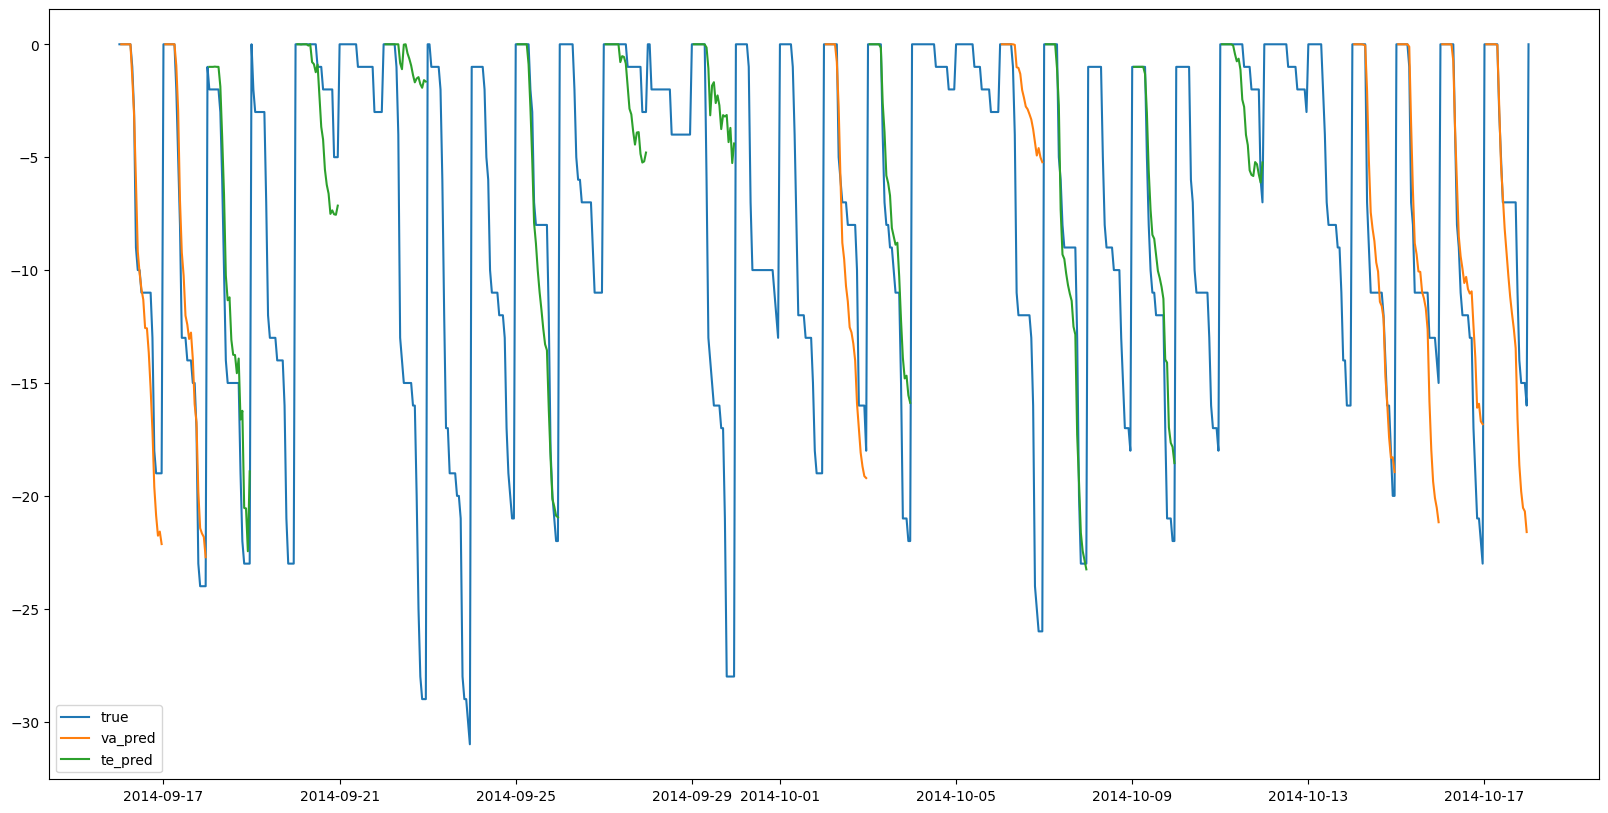

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [ ]:
timeseries_runner.run_metric_cv()

[2024-10-15 16:47:27] - lgbm_multiml_demand_202410142258 - start metric cv
100%|██████████| 12/12 [03:57<00:00, 19.77s/it]
memo: LightGBM23期マルチモデル demand_cumsum
run_name:lgbm_multiml_demand_202410142258	score_mean:2.2507819233241975	score0:2.345910104402896	score1:2.344884720360136	score2:3.0850323653663043	score3:1.3618085294342033	score4:2.1062527879190407	score5:2.4927756248810184	score6:2.3263839264255113	score7:1.6118102714642555	score8:1.6074637485535763	score9:3.0685704553691773	score10:2.3470963222588477	score11:2.3113942234554017
mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/va_pred.pkl
[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - end metric cv


In [ ]:
timeseries_runner.run_predict_cv()

[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - start prediction cv
100%|██████████| 12/12 [03:32<00:00, 17.73s/it]
[2024-10-15 16:54:58] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/te_pred.pkl
[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - end prediction cv


In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_demand[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LightGBM23期マルチモデル demand_cumsum


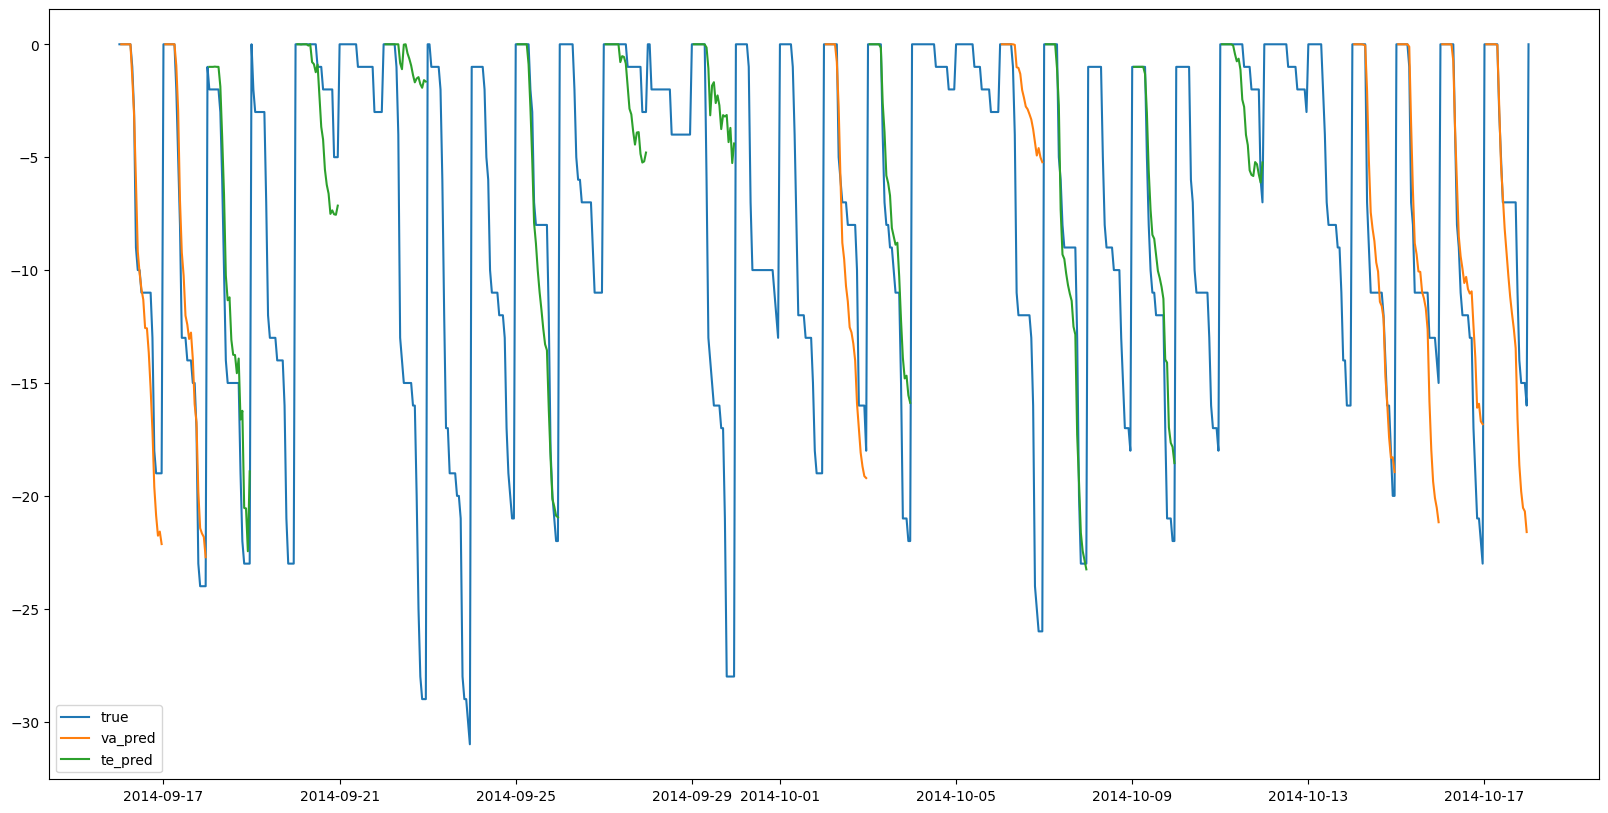

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])  # 最後のタイムステップの出力
        return out

In [11]:
model = LSTMModel(input_size=5, hidden_size=64, output_size=1, num_layers=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# LSTM_供給

In [ ]:
df_main_supply_lstm = df_key.copy()
df_main_supply_lstm = pd.merge(df_main_supply_lstm, df_predict_, on=["station_id","datetime"], how="left")
df_main_supply_lstm = pd.merge(df_main_supply_lstm, df_supply_cumsum, on=["station_id","datetime"], how="left")
df_main_supply_lstm = pd.merge(df_main_supply_lstm, df_weekday, on=["datetime"], how="left")

In [ ]:
df_main_supply_lstm.to_pickle(os.path.join(DIR_INTERIM, "df_main_supply_lstm.pkl"))

In [ ]:
df_main_supply_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_supply_lstm.pkl")) 

In [ ]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

# run_nameの設定
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

run_name = get_run_name(model_type="lstm_mult_supply")
# run_name = 'lstm_demand_202410142258'
run_name

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 正の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)

    return df_pred

model_params_lstm_supply = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "seq_length": 48,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}
run_setting_lstm_supply = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting_lstm_supply = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "supply_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LSTM supply_cumsum ベースライン"
timeseries_runner = TimeseriesModelRunner(
    run_name,
    model_LSTM_mult, 
    model_params_lstm_supply, 
    df_main_supply_lstm, 
    run_setting_lstm_supply, 
    cv_setting_lstm_supply, 
    logger, 
    memo,
)

In [ ]:
timeseries_runner.run_train_cv()

In [ ]:
timeseries_runner.run_metric_cv()

[2024-10-15 16:47:27] - lgbm_multiml_demand_202410142258 - start metric cv
100%|██████████| 12/12 [03:57<00:00, 19.77s/it]
memo: LightGBM23期マルチモデル demand_cumsum
run_name:lgbm_multiml_demand_202410142258	score_mean:2.2507819233241975	score0:2.345910104402896	score1:2.344884720360136	score2:3.0850323653663043	score3:1.3618085294342033	score4:2.1062527879190407	score5:2.4927756248810184	score6:2.3263839264255113	score7:1.6118102714642555	score8:1.6074637485535763	score9:3.0685704553691773	score10:2.3470963222588477	score11:2.3113942234554017
mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/va_pred.pkl
[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - end metric cv


In [ ]:
timeseries_runner.run_predict_cv()

[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - start prediction cv
100%|██████████| 12/12 [03:32<00:00, 17.73s/it]
[2024-10-15 16:54:58] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/te_pred.pkl
[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - end prediction cv


In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_demand[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LightGBM23期マルチモデル demand_cumsum


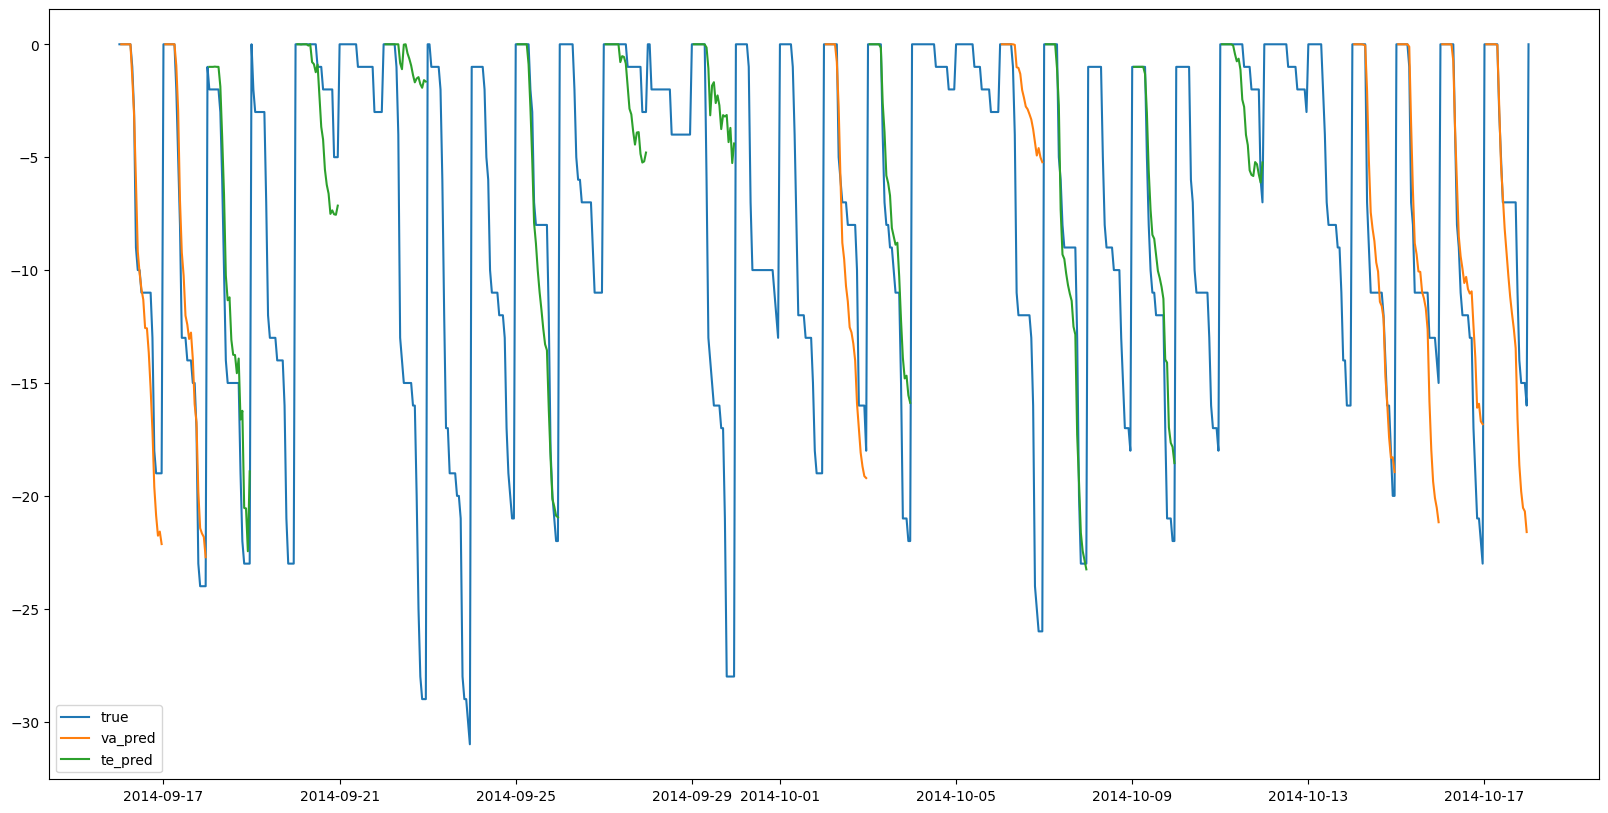

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# LSTM_介入

In [ ]:
df_main_intervention_lstm = df_key.copy()
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_predict_, on=["station_id","datetime"], how="left")
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_intervention_cumsum, on=["station_id","datetime"], how="left")
df_main_intervention_lstm = pd.merge(df_main_intervention_lstm, df_weekday, on=["datetime"], how="left")

In [ ]:
df_main_intervention_lstm.to_pickle(os.path.join(DIR_INTERIM, "df_main_intervention_lstm.pkl"))

In [ ]:
df_main_intervention_lstm = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_intervention_lstm.pkl"))

In [ ]:
import importlib
from src import runner
from src import model_LSTM_mult
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LSTM_mult)
importlib.reload(model)

# Runnerクラスを再インポート
from src.runner import TimeseriesModelRunner
from src.model_LSTM_mult import model_LSTM_mult
from src.model import Model

In [ ]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

# run_nameの設定
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

run_name = get_run_name(model_type="lstm_mult_intervention")
# run_name = 'lstm_demand_202410142258'
run_name

In [ ]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    return df_pred

model_params_lstm_intervention = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "remove_cols": ["predict"],
    # model run params
    "seq_length": 48,
    "n_steps": 23,
    "batch_size": 64,
    "shuffle": True,
    "hidden_size": 64,
    "num_epochs": 10,
    "learning_rate": 0.001,
}

run_setting_lstm_intervention = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}

cv_setting_lstm_intervention = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "intervention_cumsum",
    "initial_fold_date": "2014-09-01",
}

In [ ]:
memo = "LSTM intervention_cumsum ベースライン"
timeseries_runner = TimeseriesModelRunner(
    run_name,
    model_LSTM_mult, 
    model_params_lstm_intervention, 
    df_main_intervention_lstm, 
    run_setting_lstm_intervention, 
    cv_setting_lstm_intervention, 
    logger, 
    memo,
)

In [ ]:
timeseries_runner.run_train_cv()

[2024-10-18 00:42:32] - lstm_mult_demand_202410180039 - start training cv
[2024-10-18 00:42:32] - lstm_mult_demand_202410180039 fold 2014-09-01 - start training


In [ ]:
timeseries_runner.run_metric_cv()

[2024-10-15 16:47:27] - lgbm_multiml_demand_202410142258 - start metric cv
100%|██████████| 12/12 [03:57<00:00, 19.77s/it]
memo: LightGBM23期マルチモデル demand_cumsum
run_name:lgbm_multiml_demand_202410142258	score_mean:2.2507819233241975	score0:2.345910104402896	score1:2.344884720360136	score2:3.0850323653663043	score3:1.3618085294342033	score4:2.1062527879190407	score5:2.4927756248810184	score6:2.3263839264255113	score7:1.6118102714642555	score8:1.6074637485535763	score9:3.0685704553691773	score10:2.3470963222588477	score11:2.3113942234554017
mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - mean: 2.2507819233241975, std: 0.5077063563360704
[2024-10-15 16:51:25] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/va_pred.pkl
[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - end metric cv


In [ ]:
timeseries_runner.run_predict_cv()

[2024-10-15 16:51:25] - lgbm_multiml_demand_202410142258 - start prediction cv
100%|██████████| 12/12 [03:32<00:00, 17.73s/it]
[2024-10-15 16:54:58] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/lgbm_multiml_demand_202410142258/te_pred.pkl
[2024-10-15 16:54:58] - lgbm_multiml_demand_202410142258 - end prediction cv


In [ ]:
path_va_pred = os.path.join(timeseries_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(timeseries_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = df_main_new_demand[timeseries_runner.key_cols+[timeseries_runner.target_col]]

LightGBM23期マルチモデル demand_cumsum


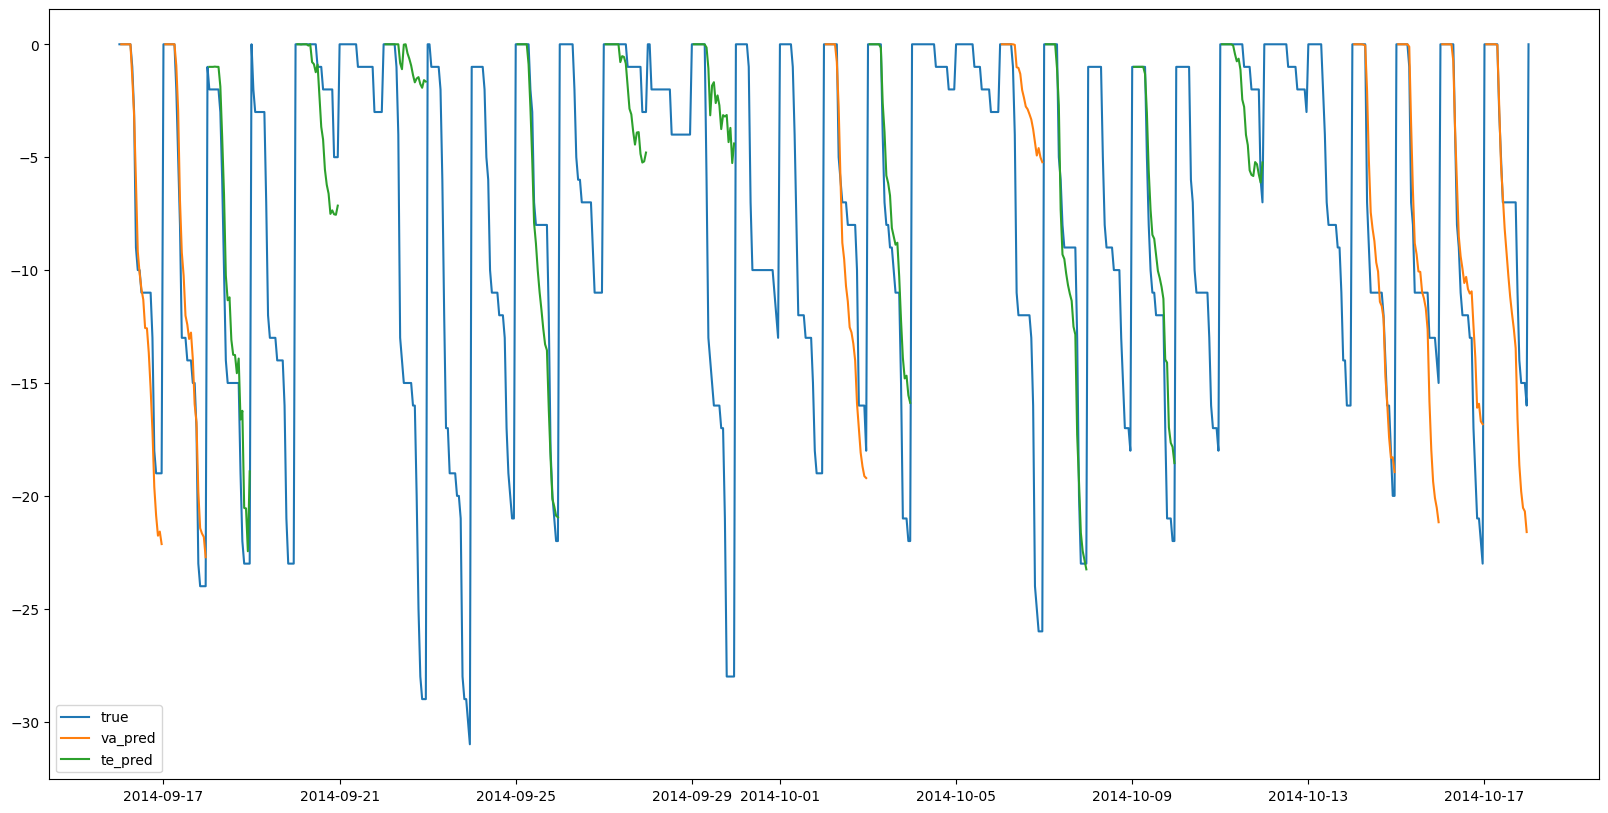

In [ ]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
target_col = timeseries_runner.target_col
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[f"{target_col}"], label="true")
plt.plot(df_["datetime"], df_[f"{target_col}_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_[f"{target_col}_te_pred"], label="te_pred")
plt.legend()
plt.show()

# 需要＋供給＋介入

In [ ]:
def after_predict_process(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [60]:
de_run_name = "lgbm_multiml_demand_202410142258"
de_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "va_pred.pkl"))
de_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, de_run_name, "te_pred.pkl"))
de_va_te_pred = pd.concat([de_va_pred, de_te_pred], axis=0)
de_va_te_pred = de_va_te_pred.drop(columns=["target"])

In [61]:
su_run_name = "lgbm_multiml_supply_202410151702"
su_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "va_pred.pkl"))
su_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, su_run_name, "te_pred.pkl"))
su_va_te_pred = pd.concat([su_va_pred, su_te_pred], axis=0)
su_va_te_pred = su_va_te_pred.drop(columns=["target"])

In [62]:
in_run_name = "lgbm_multiml_intervention_202410151853"
in_va_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "va_pred.pkl"))
in_te_pred = pd.read_pickle(os.path.join(DIR_MODEL, in_run_name, "te_pred.pkl"))
in_va_te_pred = pd.concat([in_va_pred, in_te_pred], axis=0)
in_va_te_pred = in_va_te_pred.drop(columns=["target"])

In [89]:
df_predict_ = create_add_valid_dataset(df_predict)

In [123]:
df_true_00 = df_target[df_target["datetime"].dt.hour==0][["station_id", "datetime", "bikes_available"]].copy()
df_true_00["date"] = df_true_00["datetime"].dt.date
df_true_00 = df_true_00.rename(columns={"bikes_available": "bikes_available_00"})
df_true_00 = df_true_00[["station_id", "date", "bikes_available_00"]]
df_pred = df_key.copy()
df_pred["date"] = df_pred["datetime"].dt.date
df_pred = pd.merge(df_pred, df_true_00, on=["station_id", "date"], how="left")
df_pred = df_pred[["station_id", "datetime", "bikes_available_00"]]

df_pred = df_pred.copy()
df_pred = pd.merge(df_pred, df_predict_, on=["station_id","datetime"], how="left")
df_pred = pd.merge(df_pred, de_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_de_va_pred"))
df_pred = pd.merge(df_pred, su_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_su_va_pred"))
df_pred = pd.merge(df_pred, in_va_te_pred, on=["station_id","datetime"], how="left", suffixes=("", "_in_va_pred"))

df_true = df_target[["station_id", "datetime", "bikes_available"]].copy()
df_true = pd.merge(df_true, df_predict_, on=["station_id", "datetime"], how="left")

In [128]:
df_pred["bikes_available"] = df_pred["bikes_available_00"] + df_pred["demand_cumsum"] + df_pred["supply_cumsum"] + df_pred["intervention_cumsum"]

In [129]:
df_metric = pd.merge(df_true, df_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_pred"))
df_metric = df_metric.dropna(subset=["bikes_available", "bikes_available_pred"])
df_metric = df_metric[df_metric["predict"]==2]
df_metric = df_metric.sort_values(["station_id", "datetime"])

In [130]:
from sklearn.metrics import mean_absolute_error
def metric(va_true, va_pred):
    """評価指標の計算
    """
    score = mean_absolute_error(va_true, va_pred)
    # score = math.sqrt(mean_squared_error(va_true, va_pred))
    
    return score

metric(df_metric["bikes_available"].values,
       df_metric["bikes_available_pred"].values)

1.876879464472673

# LGBM_需要＋供給＋介入

In [167]:
df_main_new_ans = df_key.copy()
df_main_new_ans = pd.merge(df_main_new_ans, df_bikes_available_fillna, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_predict_, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_demand_cumsum, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_supply_cumsum, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_intervention_cumsum, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_demand_cumsum_lag, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_supply_cumsum_lag, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_intervention_cumsum_lag, on=["station_id","datetime"], how="left")
df_main_new_ans = pd.merge(df_main_new_ans, df_weekday, on=["datetime"], how="left")

In [168]:
df_main_new_ans.to_pickle(os.path.join(DIR_INTERIM, "df_main_new_ans.pkl"))

In [169]:
df_main_new_ans = pd.read_pickle(os.path.join(DIR_INTERIM, "df_main_new_ans.pkl"))

In [38]:
def get_run_name(model_type):
    """run名の作成
    """
    run_name = model_type
    suffix = '_' + datetime.now().strftime("%Y%m%d%H%M")
    run_name = run_name + suffix
    return run_name

In [39]:
# run_nameの設定
run_name = get_run_name(model_type="ansamble_lgbm")
# run_name = 'ansamble_lgbm_202410162243'
run_name

'ansamble_lgbm_202410171957'

In [40]:
# ロガーの設定
logger = Logger(path=DIR_LOG)

In [41]:
def after_pred_func(df_pred, target_col):
    """予測後に行う処理
    Args:
        df_pred(pd.DataFrame): 予測データ[key_cols, 予測値]
    """
    # 負の値を0に変換
    df_pred[target_col] = df_pred[target_col].clip(lower=0)
    # dock_countを超えないようにする
    df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
    df_dock_count = df_prep_station[["station_id", "dock_count"]]
    df_pred = pd.merge(df_pred, df_dock_count, on="station_id", how="left")
    df_pred[target_col] = df_pred[target_col].clip(upper=df_pred["dock_count"])
    return df_pred

In [121]:
model_params_lgb = {
    # run params
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "remove_cols": ["predict"],
    # model run params
    "demand_model_cls": model_LGBM_multimodel,
    "supply_model_cls": model_LGBM_multimodel,
    "intervention_model_cls": model_LGBM_multimodel,
    "demand_run_name": "lgbm_multiml_demand_202410142258",
    "supply_run_name": "lgbm_multiml_supply_202410151702",
    "intervention_run_name": "lgbm_multiml_intervention_202410151853",
    "num_boost_round": 2000,
    "early_stopping_rounds": 100,
    "verbose": 1,
    "period": 100,
    # model core params
    "boosting_type": "gbdt",
    "objective": "regression_l1",
    "metric": "l1",
    "learning_rate": 0.01,
}
run_setting = {
    'calc_shap': False,     # shap値を計算するか否か
    'save_train_pred': False,    # trainデータに対する予測値を保存するか否か(閾値の最適化に使用)
    "tune_params": True,           # パラメータチューニング、lgb_hopt,xgb_hopt,nn_hopt,False
    "target_encoder": None, #TargetEncodingBlock(use_cache=False),     # target encodingをしない場合はNone
    "after_pred_func": after_pred_func,
}
cv_setting = {
    "key_cols": ["datetime", "station_id"],
    "target_col": "bikes_available",
    "initial_fold_date": "2014-09-01",
}

In [170]:
import sys
sys.path.append(DIR_HOME)
from src.runner import MLModelRunner
from src.model_ASMBL import model_ASMBL_demand_supply_intervention
from src.model_LGBM import model_LGBM_multimodel
from datetime import datetime
from src.util import Logger

In [174]:
import importlib
from src import runner
from src import model_LGBM
from src import model_ASMBL
from src import model

# runnerモジュールをリロード
importlib.reload(runner)
importlib.reload(model_LGBM)
importlib.reload(model_ASMBL)
importlib.reload(model)

# Runnerクラスを再インポート
from src.model import Model
from src.runner import MLModelRunner
from src.model_LGBM import model_LGBM_multimodel
from src.model_ASMBL import model_ASMBL_demand_supply_intervention

In [175]:
memo = "アンサンブルLGBM ベースライン"
ml_runner = MLModelRunner(
    run_name,
    model_ASMBL_demand_supply_intervention, 
    model_params_lgb, 
    df_main_new_ans, 
    run_setting, 
    cv_setting, 
    logger, 
    memo)

In [176]:
# ml_runner.run_train_cv()

In [177]:
ml_runner.run_metric_cv()

[2024-10-18 00:25:13] - ansamble_lgbm_202410171957 - start metric cv
  0%|          | 0/12 [00:00<?, ?it/s]

(10080, 83)


  8%|▊         | 1/12 [00:27<05:01, 27.36s/it]

(10080, 83)


 17%|█▋        | 2/12 [00:50<04:07, 24.75s/it]

...

 83%|████████▎ | 10/12 [04:38<00:57, 28.73s/it]

(8400, 83)


 92%|█████████▏| 11/12 [05:09<00:29, 29.26s/it]

(8400, 83)


100%|██████████| 12/12 [05:39<00:00, 28.29s/it]
memo: アンサンブルLGBM ベースライン
run_name:ansamble_lgbm_202410171957	score_mean:1.6723901286604053	score0:1.727677756413918	score1:1.9355701532712462	score2:1.5848849872761737	score3:1.5670274744746673	score4:1.6864676063980257	score5:1.4290685636210732	score6:1.6596108911811882	score7:1.6431221793277166	score8:1.6596329340896705	score9:1.75650352786577	score10:1.7835119798154075	score11:1.6356034901900067
mean: 1.6723901286604053, std: 0.11987545602176336
[2024-10-18 00:30:52] - mean: 1.6723901286604053, std: 0.11987545602176336
[2024-10-18 00:30:52] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/ansamble_lgbm_202410171957/va_pred.pkl
[2024-10-18 00:30:52] - ansamble_lgbm_202410171957 - end metric cv


In [180]:
ml_runner.run_predict_cv()

[2024-10-18 00:30:54] - ansamble_lgbm_202410171957 - start prediction cv
100%|██████████| 12/12 [06:24<00:00, 32.06s/it]
[2024-10-18 00:37:18] - output predict : /Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/models/ansamble_lgbm_202410171957/te_pred.pkl
[2024-10-18 00:37:18] - ansamble_lgbm_202410171957 - end prediction cv


In [181]:
path_va_pred = os.path.join(ml_runner.out_dir_name, "va_pred.pkl")
path_te_pred = os.path.join(ml_runner.out_dir_name, "te_pred.pkl")
df_va_pred = pd.read_pickle(path_va_pred)
df_te_pred = pd.read_pickle(path_te_pred)

df_true = pd.read_pickle(os.path.join(DIR_INTERIM, "status_data.pkl"))[ml_runner.key_cols+[ml_runner.target_col]]

アンサンブルLGBM ベースライン


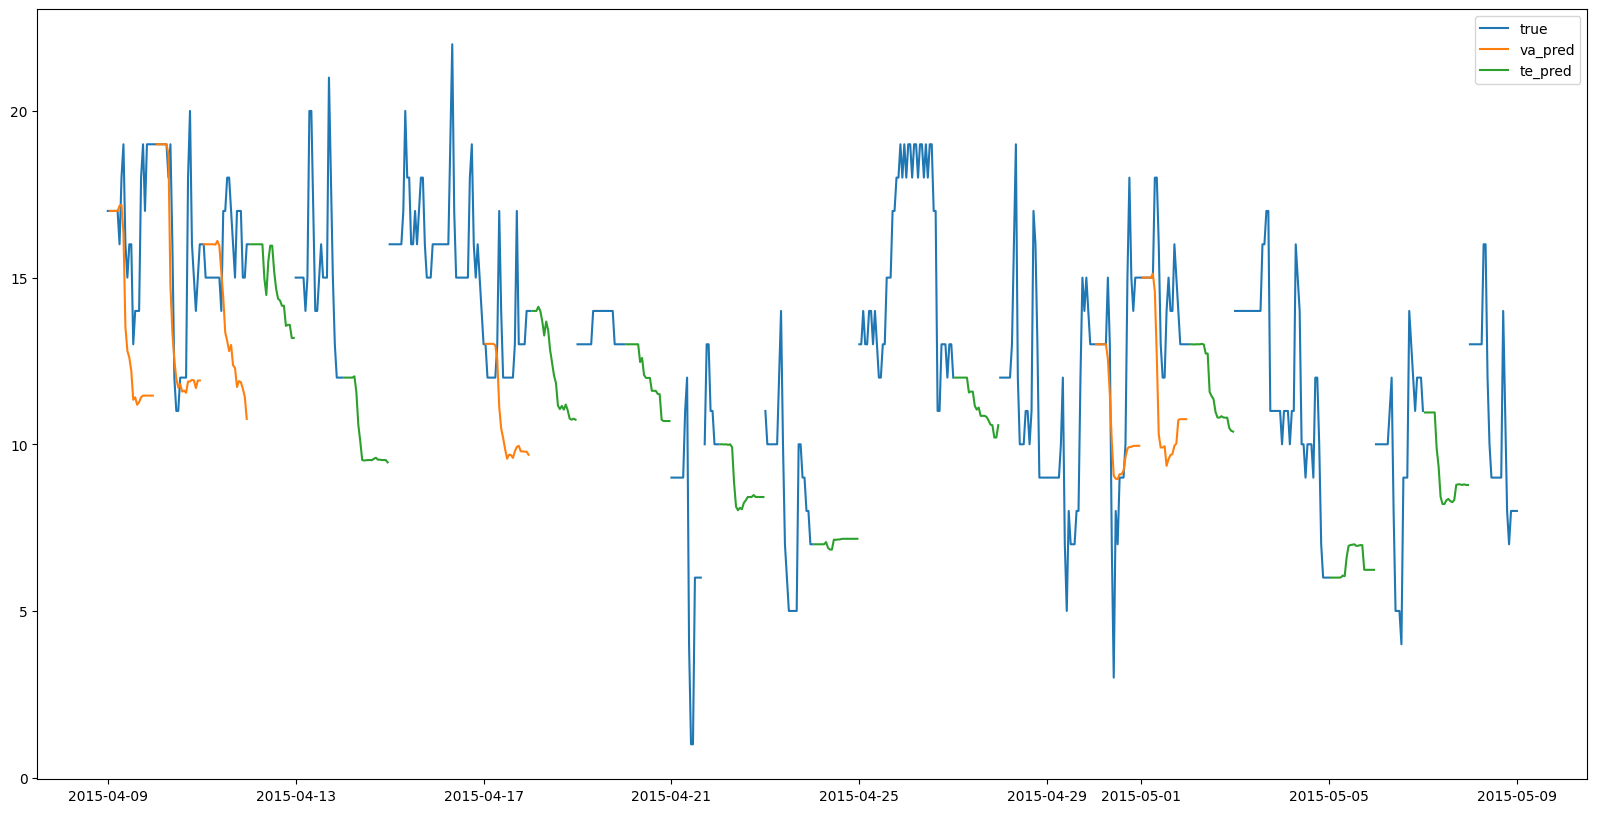

In [182]:
print(memo)
# datetimeを連続にする
df_ = pd.merge(df_true, df_va_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_va_pred"))
df_ = pd.merge(df_, df_te_pred, on=["station_id", "datetime"], how="left", suffixes=("", "_te_pred"))
# データ期間,station_idを指定する
station_id = 0
start_date = "2015-04-09"
end_date = "2015-05-09"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
# プロット
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_["bikes_available"], label="true")
plt.plot(df_["datetime"], df_["bikes_available_va_pred"], label="va_pred")
plt.plot(df_["datetime"], df_["bikes_available_te_pred"], label="te_pred")
plt.legend()
plt.show()

# Submissionの作成

In [46]:
runner = ml_runner

In [47]:
path_te_pred = os.path.join(runner.out_dir_name, "te_pred.pkl")
df_te_pred = pd.read_pickle(path_te_pred)
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))[["id", "datetime", "station_id", "predict"]]

In [48]:
df_submit = pd.merge(df_prep_status, df_te_pred, on=["datetime", "station_id"], how="left")

In [52]:
df_prep_station

,station_id,lat,long,dock_count,city,installation_date
0,0,37.32973,-121.90178,27,city1,2013-08-06
1,1,37.33070,-121.88898,15,city1,2013-08-05
2,2,37.33399,-121.89490,11,city1,2013-08-06
3,3,37.33141,-121.89320,19,city1,2013-08-05
4,4,37.33672,-121.89407,15,city1,2013-08-07
...,...,...,...,...,...,...
65,65,37.78963,-122.40081,27,city2,2013-08-25
66,66,37.35260,-121.90573,15,city1,2013-12-31
67,67,37.79854,-122.40086,15,city2,2014-01-22
68,68,37.49127,-122.23623,15,city3,2014-02-20


In [44]:
df_sample_submit = pd.read_csv(os.path.join(DIR_INPUT, "sample_submit.csv"), header=None, names=["id", "b_a"])
df_submit = pd.merge(df_sample_submit, df_submit, on=["id"], how="left")[["id", "bikes_available"]]
path_submit = os.path.join(DIR_SUBMISSION, f"{runner.run_name}_submit.csv")
df_submit.to_csv(path_submit, header=False, index=False)
print(path_submit)

/Users/ishizuka/pyworks/Competitions/signate_mufgcup2024/data/submission/lgbm_multimodel_202410132324_submit.csv


In [45]:
pd.read_csv(path_submit, header=None)

,0,1
0,8761,14.999987
1,8762,15.000038
2,8763,14.999989
3,8764,14.993988
4,8765,14.965969
...,...,...
193195,1226347,9.725839
193196,1226348,9.529384
193197,1226349,10.058437
193198,1226350,10.155552


In [257]:
pd.read_csv(path_submit, header=None).isnull().sum()

0    0
1    0
dtype: int64